# EDA completo — dívida inscrita PGE (base Lívia)

Notebook único, etapa a etapa. **Etapa 0 = setup.** As demais seções entram depois, com você supervisionando.

**Fonte padrão (Mac + HD Meedi):** `/Volumes/Meedi_Etore_HD1/CEMEPI/api_ctf/`

Opcional no shell antes de abrir o kernel:
```bash
export DATA_ROOT="/Volumes/Meedi_Etore_HD1/CEMEPI/api_ctf/"
```

**Stack:** Polars (+ DuckDB só para `ATTACH`/`COUNT` em `.duckdb`). Sem pandas.



In [9]:
from __future__ import annotations

import os
from pathlib import Path

import polars as pl
import plotly.express as px

DEFAULT_DATA_ROOT = Path("/Volumes/Meedi_Etore_HD1/CEMEPI/api_ctf")
DATA_ROOT = Path(os.environ.get("DATA_ROOT", str(DEFAULT_DATA_ROOT))).expanduser()

fonte_ok = DATA_ROOT.is_dir()
print(f"polars {pl.__version__}")
print(f"DATA_ROOT = {DATA_ROOT}")
if fonte_ok:
    print("FONTE OK — pasta existe.")
    nomes = sorted(p.name for p in DATA_ROOT.iterdir())[:30]
    print(f"itens no root (até 30): {nomes}")
else:
    print("FONTE NÃO MONTADA — monte o HD Meedi ou ajuste DATA_ROOT.")
    print("Próximo passo: export DATA_ROOT=... e rode esta célula de novo.")


polars 1.44.2
DATA_ROOT = /Volumes/Meedi_Etore_HD1/CEMEPI/api_ctf
FONTE OK — pasta existe.
itens no root (até 30): ['.DS_Store', '_duckdb_tmp_eda', 'cemepi.duckdb', 'cemepi_api.duckdb', 'exports', 'macro.duckdb']


### DoD — etapa 0
- Célula de setup roda sem crash.
- Imprime `FONTE OK` ou `FONTE NÃO MONTADA` de forma explícita.
- **Não** inventa contagens nem abre débito ainda.


In [2]:
assert "fonte_ok" in dir() or "fonte_ok" in globals()
print("DoD etapa 0:", "PASS" if fonte_ok else "PASS (fonte ausente, aviso emitido)")


DoD etapa 0: PASS


## 1. Inventário / sanidade (fatiado)

Uma célula = uma tabela, **base completa** (sem amostra). Ordem: leve → pesado. `DEBITO` (~800M) por último.

Helper Polars/DuckDB abaixo; depois rode só a próxima tabela.


In [4]:
from __future__ import annotations

from typing import Any

import duckdb
import polars as pl

assert "DATA_ROOT" in globals() and "fonte_ok" in globals(), "Rode a etapa 0."
inventario: list[dict[str, Any]] = []
ARTIFACTS = Path.cwd() / "eda_completo_artifacts"
ARTIFACTS.mkdir(exist_ok=True)
CACHE_JSON = ARTIFACTS / "inventario.json"


def _save_inventario() -> None:
    """Persiste após cada tabela — não precisa rerodar o censo."""
    import json as _json
    slim = []
    for r in inventario:
        slim.append({
            "label": r.get("label"),
            "n": r.get("n"),
            "ncols": r.get("ncols"),
            "cols": r.get("cols"),
            "null_pct": r.get("null_pct"),
            "ranges": {k: [str(a), str(b)] for k, (a, b) in (r.get("ranges") or {}).items()},
        })
    CACHE_JSON.write_text(_json.dumps(slim, ensure_ascii=False, indent=2), encoding="utf-8")
    print(f"cache → {CACHE_JSON}")


def load_inventario() -> list[dict[str, Any]]:
    import json as _json
    if not CACHE_JSON.is_file():
        print("sem cache ainda")
        return []
    data = _json.loads(CACHE_JSON.read_text(encoding="utf-8"))
    print(f"carregou {len(data)} relações de {CACHE_JSON}")
    return data


def describe_duckdb_table(db_name: str, table: str) -> dict[str, Any]:
    """Censo completo de UMA tabela (SQL). Rode célula a célula."""
    db = DATA_ROOT / db_name
    label = f"{db_name}:{table}"
    if any(r.get("label") == label for r in inventario):
        print(f"já no cache — skip {label}")
        return next(r for r in inventario if r.get("label") == label)
    if not fonte_ok or not db.is_file():
        print(f"FONTE/arquivo ausente — skip {label}")
        return {"label": label, "n": None, "skipped": True}

    con = duckdb.connect()
    alias = "dbx"
    try:
        con.execute(f"ATTACH '{db}' AS {alias} (READ_ONLY)")
        rel = f'{alias}."{table}"'
        print(f"… {label} COUNT(*) …")
        n = int(con.execute(f"SELECT COUNT(*) FROM {rel}").fetchone()[0])
        cols_df = con.execute(f"DESCRIBE SELECT * FROM {rel}").pl()
        col_names = cols_df["column_name"].to_list()

        print(f"… {label} % nulos ({len(col_names)} cols) …")
        null_exprs = ", ".join(
            f'AVG(CASE WHEN "{c}" IS NULL THEN 1.0 ELSE 0.0 END) AS "{c}"' for c in col_names
        )
        null_row = con.execute(f"SELECT {null_exprs} FROM {rel}").fetchone()
        null_pct = {c: float(null_row[i] or 0.0) for i, c in enumerate(col_names)}

        dateish = [c for c in col_names if any(k in c.lower() for k in ("data", "date", "dt_", "ano", "mes"))]
        ranges: dict[str, tuple[Any, Any]] = {}
        for c in dateish:
            lo, hi = con.execute(f'SELECT MIN("{c}"), MAX("{c}") FROM {rel}').fetchone()
            ranges[c] = (lo, hi)

        print(f"\n=== {label} ===")
        print(f"linhas={n:,}  colunas={len(col_names)}  [BASE COMPLETA]")
        if ranges:
            print("intervalos:")
            for c, (lo, hi) in ranges.items():
                print(f"  {c}: {lo} → {hi}")
        for c, v in sorted(null_pct.items(), key=lambda x: -x[1])[:15]:
            print(f"  null {c}: {100*v:.1f}%")

        row = {"label": label, "n": n, "ncols": len(col_names), "cols": col_names, "null_pct": null_pct, "ranges": ranges}
        inventario.append(row)
        _save_inventario()
        return row
    finally:
        try:
            con.execute(f"DETACH {alias}")
        except Exception:
            pass
        con.close()


# Não zera progresso: se já existe cache, carrega
if CACHE_JSON.is_file():
    inventario = load_inventario()
else:
    inventario = []

print("helper ok — tabelas já no cache:", [r.get("label") for r in inventario])
print("rode só as células que ainda faltam.")


carregou 8 relações de /Users/etorebraga/Code/cemepi-ctf-intel-fiscal/projects/macro/notebooks/eda_completo_artifacts/inventario.json
helper ok — tabelas já no cache: ['macro.duckdb:MACRO', 'cemepi.duckdb:AJUIZAMENTO', 'cemepi.duckdb:ARRECADACAO', 'cemepi.duckdb:DEBITO_RECEITA', 'cemepi.duckdb:SOLICITACAOPARCELAMENTO', 'cemepi.duckdb:STATUS_PROTESTO', 'cemepi.duckdb:FATURAMENTO_MASCARADO', 'cemepi.duckdb:DEBITO']
rode só as células que ainda faltam.


### `macro.duckdb` → `MACRO`


In [4]:
describe_duckdb_table("macro.duckdb", "MACRO")


… macro.duckdb:MACRO COUNT(*) …
… macro.duckdb:MACRO % nulos (6 cols) …

=== macro.duckdb:MACRO ===
linhas=20,522  colunas=6  [BASE COMPLETA]
intervalos:
  data: 1963-01-01 → 2026-11-04
  null codigo_serie: 0.0%
  null nome: 0.0%
  null unidade: 0.0%
  null data: 0.0%
  null valor: 0.0%
  null fonte: 0.0%
cache → /Users/etorebraga/Code/cemepi-ctf-intel-fiscal/projects/macro/notebooks/eda_completo_artifacts/inventario.json


{'label': 'macro.duckdb:MACRO',
 'n': 20522,
 'ncols': 6,
 'cols': ['codigo_serie', 'nome', 'unidade', 'data', 'valor', 'fonte'],
 'null_pct': {'codigo_serie': 0.0,
  'nome': 0.0,
  'unidade': 0.0,
  'data': 0.0,
  'valor': 0.0,
  'fonte': 0.0},
 'ranges': {'data': (datetime.date(1963, 1, 1), datetime.date(2026, 11, 4))}}

### `cemepi.duckdb` → `AJUIZAMENTO`


In [5]:
describe_duckdb_table("cemepi.duckdb", "AJUIZAMENTO")


… cemepi.duckdb:AJUIZAMENTO COUNT(*) …
… cemepi.duckdb:AJUIZAMENTO % nulos (5 cols) …

=== cemepi.duckdb:AJUIZAMENTO ===
linhas=1,850,991  colunas=5  [BASE COMPLETA]
intervalos:
  DT_INSCRICAO: 2016-01-04 → 2026-04-18
  DT_AJUIZAMENTO: 1997-05-05 → 2026-04-27
  null PEF: 0.0%
  null NOMECOMARCA: 0.0%
  null ID_DEBITO: 0.0%
  null DT_INSCRICAO: 0.0%
  null DT_AJUIZAMENTO: 0.0%
cache → /Users/etorebraga/Code/cemepi-ctf-intel-fiscal/projects/macro/notebooks/eda_completo_artifacts/inventario.json


{'label': 'cemepi.duckdb:AJUIZAMENTO',
 'n': 1850991,
 'ncols': 5,
 'cols': ['ID_DEBITO', 'DT_INSCRICAO', 'PEF', 'DT_AJUIZAMENTO', 'NOMECOMARCA'],
 'null_pct': {'ID_DEBITO': 0.0,
  'DT_INSCRICAO': 0.0,
  'PEF': 2.1610045645818917e-05,
  'DT_AJUIZAMENTO': 0.0,
  'NOMECOMARCA': 6.4830136937456745e-06},
 'ranges': {'DT_INSCRICAO': (datetime.date(2016, 1, 4),
   datetime.date(2026, 4, 18)),
  'DT_AJUIZAMENTO': (datetime.date(1997, 5, 5), datetime.date(2026, 4, 27))}}

### `cemepi.duckdb` → `ARRECADACAO`


In [6]:
describe_duckdb_table("cemepi.duckdb", "ARRECADACAO")


… cemepi.duckdb:ARRECADACAO COUNT(*) …
… cemepi.duckdb:ARRECADACAO % nulos (14 cols) …

=== cemepi.duckdb:ARRECADACAO ===
linhas=23,199,305  colunas=14  [BASE COMPLETA]
intervalos:
  ANO: 2016 → 2026
  MES: 1 → 12
  DATA_ARRECADACAO_GARE: 2016-01-04 00:00:00 → 2026-03-31 00:00:00
  null HONORARIOS_ADMINISTRATIVOS: 83.6%
  null VALOR_ACRESCIMO_FINANCEIRO: 41.6%
  null JUROS_MORA: 41.6%
  null MULTA_MORA: 41.6%
  null HONORARIOS_ADVOCATICIOS: 41.0%
  null VALOR_RECEITA: 20.7%
  null ANO: 0.0%
  null MES: 0.0%
  null ID_DEBITO: 0.0%
  null CDA_COMPLETA: 0.0%
  null STATUS_AJUIZAMENTO_DEBITO: 0.0%
  null ID_GARE_SEFAZ: 0.0%
  null DATA_ARRECADACAO_GARE: 0.0%
  null VALOR_TOTAL_GARE: 0.0%
cache → /Users/etorebraga/Code/cemepi-ctf-intel-fiscal/projects/macro/notebooks/eda_completo_artifacts/inventario.json


{'label': 'cemepi.duckdb:ARRECADACAO',
 'n': 23199305,
 'ncols': 14,
 'cols': ['ANO',
  'MES',
  'ID_DEBITO',
  'CDA_COMPLETA',
  'STATUS_AJUIZAMENTO_DEBITO',
  'ID_GARE_SEFAZ',
  'DATA_ARRECADACAO_GARE',
  'VALOR_TOTAL_GARE',
  'VALOR_RECEITA',
  'JUROS_MORA',
  'MULTA_MORA',
  'VALOR_ACRESCIMO_FINANCEIRO',
  'HONORARIOS_ADMINISTRATIVOS',
  'HONORARIOS_ADVOCATICIOS'],
 'null_pct': {'ANO': 0.0,
  'MES': 0.0,
  'ID_DEBITO': 0.0,
  'CDA_COMPLETA': 0.0,
  'STATUS_AJUIZAMENTO_DEBITO': 0.0,
  'ID_GARE_SEFAZ': 0.0,
  'DATA_ARRECADACAO_GARE': 0.0,
  'VALOR_TOTAL_GARE': 0.0,
  'VALOR_RECEITA': 0.20704753870859494,
  'JUROS_MORA': 0.4162044940570418,
  'MULTA_MORA': 0.416203588857511,
  'VALOR_ACRESCIMO_FINANCEIRO': 0.41628035839866756,
  'HONORARIOS_ADMINISTRATIVOS': 0.8364736788451206,
  'HONORARIOS_ADVOCATICIOS': 0.4100784915755019},
 'ranges': {'ANO': (2016, 2026),
  'MES': (1, 12),
  'DATA_ARRECADACAO_GARE': (datetime.datetime(2016, 1, 4, 0, 0),
   datetime.datetime(2026, 3, 31, 0, 0))}}

### `cemepi.duckdb` → `DEBITO_RECEITA`


In [7]:
describe_duckdb_table("cemepi.duckdb", "DEBITO_RECEITA")


… cemepi.duckdb:DEBITO_RECEITA COUNT(*) …
… cemepi.duckdb:DEBITO_RECEITA % nulos (18 cols) …

=== cemepi.duckdb:DEBITO_RECEITA ===
linhas=7,754,477  colunas=18  [BASE COMPLETA]
intervalos:
  DT_INSCRICAO: 2016-01-04 → 2026-04-27
  DT_CONSULTA: 2026-04-27 → 2026-04-27
  null ID_DEBITO: 0.0%
  null DT_INSCRICAO: 0.0%
  null DT_CONSULTA: 0.0%
  null ID_SITUACAO: 0.0%
  null VL_PRINCIPAL: 0.0%
  null VL_CORRECAO: 0.0%
  null VL_JUROS_MORA_PRINCIPAL: 0.0%
  null VL_MULTA_MORA_PRINCIPAL: 0.0%
  null VL_MULTA_PUNITIVA: 0.0%
  null VL_CORRECAO_MONETARIA_MULTA_PUNITIVA: 0.0%
  null VL_JUROS_MORA_MULTA_PUNITIVA: 0.0%
  null VL_CUSTAS_JUDICIAIS: 0.0%
  null VL_DESPESAS_PROCESSUAIS: 0.0%
  null VL_JUROS_VINCENDOS: 0.0%
  null VL_ACRESCIMO_FINANCEIRO: 0.0%
cache → /Users/etorebraga/Code/cemepi-ctf-intel-fiscal/projects/macro/notebooks/eda_completo_artifacts/inventario.json


{'label': 'cemepi.duckdb:DEBITO_RECEITA',
 'n': 7754477,
 'ncols': 18,
 'cols': ['ID_DEBITO',
  'DT_INSCRICAO',
  'DT_CONSULTA',
  'ID_SITUACAO',
  'VL_PRINCIPAL',
  'VL_CORRECAO',
  'VL_JUROS_MORA_PRINCIPAL',
  'VL_MULTA_MORA_PRINCIPAL',
  'VL_MULTA_PUNITIVA',
  'VL_CORRECAO_MONETARIA_MULTA_PUNITIVA',
  'VL_JUROS_MORA_MULTA_PUNITIVA',
  'VL_CUSTAS_JUDICIAIS',
  'VL_DESPESAS_PROCESSUAIS',
  'VL_JUROS_VINCENDOS',
  'VL_ACRESCIMO_FINANCEIRO',
  'VL_MULTA_MORATORIA',
  'VL_MULTA_POR_ATRASO',
  'VL_JUROS_MORA_MULTA_MORA'],
 'null_pct': {'ID_DEBITO': 0.0,
  'DT_INSCRICAO': 0.0,
  'DT_CONSULTA': 0.0,
  'ID_SITUACAO': 0.0,
  'VL_PRINCIPAL': 0.0,
  'VL_CORRECAO': 0.0,
  'VL_JUROS_MORA_PRINCIPAL': 0.0,
  'VL_MULTA_MORA_PRINCIPAL': 0.0,
  'VL_MULTA_PUNITIVA': 0.0,
  'VL_CORRECAO_MONETARIA_MULTA_PUNITIVA': 0.0,
  'VL_JUROS_MORA_MULTA_PUNITIVA': 0.0,
  'VL_CUSTAS_JUDICIAIS': 0.0,
  'VL_DESPESAS_PROCESSUAIS': 0.0,
  'VL_JUROS_VINCENDOS': 0.0,
  'VL_ACRESCIMO_FINANCEIRO': 0.0,
  'VL_MULTA_MORATORIA'

### `cemepi.duckdb` → `SOLICITACAOPARCELAMENTO`


In [8]:
describe_duckdb_table("cemepi.duckdb", "SOLICITACAOPARCELAMENTO")


… cemepi.duckdb:SOLICITACAOPARCELAMENTO COUNT(*) …
… cemepi.duckdb:SOLICITACAOPARCELAMENTO % nulos (11 cols) …

=== cemepi.duckdb:SOLICITACAOPARCELAMENTO ===
linhas=2,715,674  colunas=11  [BASE COMPLETA]
intervalos:
  DATA_SOLICITACAO: 2016-01-12 → 2026-04-27
  DATA_ROMPIMENTO: 0502-04-12 → 3024-02-19
  DT_INSCRICAO: 2016-01-04 → 2026-04-25
  DT_CONSULTA: 2026-04-27 → 2026-04-27
  null DATA_ROMPIMENTO: 69.9%
  null VIGENCIA_PARCELAMENTO: 29.6%
  null ID_SOLICITACAOPARCELAMENTO: 0.0%
  null DATA_SOLICITACAO: 0.0%
  null STATUS_PARCELAMENTO: 0.0%
  null QTD_PARCELAS: 0.0%
  null TIPO_PARCELAMENTO: 0.0%
  null REGRA_PARCELAMENTO: 0.0%
  null ID_DEBITO: 0.0%
  null DT_INSCRICAO: 0.0%
  null DT_CONSULTA: 0.0%
cache → /Users/etorebraga/Code/cemepi-ctf-intel-fiscal/projects/macro/notebooks/eda_completo_artifacts/inventario.json


{'label': 'cemepi.duckdb:SOLICITACAOPARCELAMENTO',
 'n': 2715674,
 'ncols': 11,
 'cols': ['ID_SOLICITACAOPARCELAMENTO',
  'DATA_SOLICITACAO',
  'STATUS_PARCELAMENTO',
  'DATA_ROMPIMENTO',
  'QTD_PARCELAS',
  'TIPO_PARCELAMENTO',
  'VIGENCIA_PARCELAMENTO',
  'REGRA_PARCELAMENTO',
  'ID_DEBITO',
  'DT_INSCRICAO',
  'DT_CONSULTA'],
 'null_pct': {'ID_SOLICITACAOPARCELAMENTO': 0.0,
  'DATA_SOLICITACAO': 0.0,
  'STATUS_PARCELAMENTO': 0.0,
  'DATA_ROMPIMENTO': 0.6987977938441802,
  'QTD_PARCELAS': 0.0,
  'TIPO_PARCELAMENTO': 0.0,
  'VIGENCIA_PARCELAMENTO': 0.29564852040414275,
  'REGRA_PARCELAMENTO': 0.0,
  'ID_DEBITO': 0.0,
  'DT_INSCRICAO': 0.0,
  'DT_CONSULTA': 0.0},
 'ranges': {'DATA_SOLICITACAO': (datetime.date(2016, 1, 12),
   datetime.date(2026, 4, 27)),
  'DATA_ROMPIMENTO': (datetime.date(502, 4, 12), datetime.date(3024, 2, 19)),
  'DT_INSCRICAO': (datetime.date(2016, 1, 4), datetime.date(2026, 4, 25)),
  'DT_CONSULTA': (datetime.date(2026, 4, 27), datetime.date(2026, 4, 27))}}

### `cemepi.duckdb` → `STATUS_PROTESTO`


In [9]:
describe_duckdb_table("cemepi.duckdb", "STATUS_PROTESTO")


… cemepi.duckdb:STATUS_PROTESTO COUNT(*) …
… cemepi.duckdb:STATUS_PROTESTO % nulos (5 cols) …

=== cemepi.duckdb:STATUS_PROTESTO ===
linhas=18,889,381  colunas=5  [BASE COMPLETA]
intervalos:
  DT_INSCRICAO: 2016-01-04 → 2026-04-22
  DATA_PROTESTO: 2015-03-09 → 2026-04-24
  null DATA_PROTESTO: 19.1%
  null ID_DEBITO: 0.0%
  null DT_INSCRICAO: 0.0%
  null STATUS_PROTESTO: 0.0%
  null VALOR_PROTESTADO: 0.0%
cache → /Users/etorebraga/Code/cemepi-ctf-intel-fiscal/projects/macro/notebooks/eda_completo_artifacts/inventario.json


{'label': 'cemepi.duckdb:STATUS_PROTESTO',
 'n': 18889381,
 'ncols': 5,
 'cols': ['ID_DEBITO',
  'DT_INSCRICAO',
  'STATUS_PROTESTO',
  'DATA_PROTESTO',
  'VALOR_PROTESTADO'],
 'null_pct': {'ID_DEBITO': 0.0,
  'DT_INSCRICAO': 0.0,
  'STATUS_PROTESTO': 0.0,
  'DATA_PROTESTO': 0.19137731405809433,
  'VALOR_PROTESTADO': 0.0},
 'ranges': {'DT_INSCRICAO': (datetime.date(2016, 1, 4),
   datetime.date(2026, 4, 22)),
  'DATA_PROTESTO': (datetime.date(2015, 3, 9), datetime.date(2026, 4, 24))}}

### `cemepi.duckdb` → `FATURAMENTO_MASCARADO`


In [10]:
describe_duckdb_table("cemepi.duckdb", "FATURAMENTO_MASCARADO")


… cemepi.duckdb:FATURAMENTO_MASCARADO COUNT(*) …
… cemepi.duckdb:FATURAMENTO_MASCARADO % nulos (5 cols) …

=== cemepi.duckdb:FATURAMENTO_MASCARADO ===
linhas=28,337,827  colunas=5  [BASE COMPLETA]
intervalos:
  MES_ANO_REFERENCIA: 2022-01-01 00:00:00 → 2026-02-01 00:00:00
  DT_CONSULTA: 2022-02-13 → 2026-04-18
  null ID_FATURAMENTO: 0.0%
  null CNPJ: 0.0%
  null MES_ANO_REFERENCIA: 0.0%
  null VL_FATURAMENTO: 0.0%
  null DT_CONSULTA: 0.0%
cache → /Users/etorebraga/Code/cemepi-ctf-intel-fiscal/projects/macro/notebooks/eda_completo_artifacts/inventario.json


{'label': 'cemepi.duckdb:FATURAMENTO_MASCARADO',
 'n': 28337827,
 'ncols': 5,
 'cols': ['ID_FATURAMENTO',
  'CNPJ',
  'MES_ANO_REFERENCIA',
  'VL_FATURAMENTO',
  'DT_CONSULTA'],
 'null_pct': {'ID_FATURAMENTO': 0.0,
  'CNPJ': 0.0,
  'MES_ANO_REFERENCIA': 0.0,
  'VL_FATURAMENTO': 0.0,
  'DT_CONSULTA': 0.0},
 'ranges': {'MES_ANO_REFERENCIA': (datetime.datetime(2022, 1, 1, 0, 0),
   datetime.datetime(2026, 2, 1, 0, 0)),
  'DT_CONSULTA': (datetime.date(2022, 2, 13), datetime.date(2026, 4, 18))}}

### `cemepi.duckdb` → `DEBITO`


In [11]:
describe_duckdb_table("cemepi.duckdb", "DEBITO")


… cemepi.duckdb:DEBITO COUNT(*) …
… cemepi.duckdb:DEBITO % nulos (16 cols) …

=== cemepi.duckdb:DEBITO ===
linhas=801,844,918  colunas=16  [BASE COMPLETA]
intervalos:
  ANO_EXTRACAO: 2 → 20242024
  MES_EXTRACAO: 1 → 2025
  DATA_INSCRICAO:  00:00:00.0 → :00:00.0
  null HONORARIOS_ADMINISTRATIVOS: 76.6%
  null CNPJ_DEVEDOR: 59.0%
  null CPF_DEVEDOR: 41.0%
  null DATA_INSCRICAO: 0.0%
  null NOME_DEVEDOR: 0.0%
  null TIPO_DEBITO: 0.0%
  null MES_EXTRACAO: 0.0%
  null STATUS_AJUIZAMENTO_DEBITO: 0.0%
  null VALOR_VH: 0.0%
  null ID_DEBITO: 0.0%
  null CDA_COMPLETA: 0.0%
  null SITUACAO_DEBITO: 0.0%
  null VALOR_COM_VH: 0.0%
  null ID_HT_EXTRACAO_REL_SGR: 0.0%
  null ANO_EXTRACAO: 0.0%
cache → /Users/etorebraga/Code/cemepi-ctf-intel-fiscal/projects/macro/notebooks/eda_completo_artifacts/inventario.json


{'label': 'cemepi.duckdb:DEBITO',
 'n': 801844918,
 'ncols': 16,
 'cols': ['ID_HT_EXTRACAO_REL_SGR',
  'ANO_EXTRACAO',
  'MES_EXTRACAO',
  'ID_DEBITO',
  'CDA_COMPLETA',
  'DATA_INSCRICAO',
  'SITUACAO_DEBITO',
  'TIPO_DEBITO',
  'STATUS_AJUIZAMENTO_DEBITO',
  'VALOR_COM_VH',
  'VALOR_SEM_HONORARIOS',
  'VALOR_VH',
  'HONORARIOS_ADMINISTRATIVOS',
  'NOME_DEVEDOR',
  'CNPJ_DEVEDOR',
  'CPF_DEVEDOR'],
 'null_pct': {'ID_HT_EXTRACAO_REL_SGR': 1.2471239482246117e-09,
  'ANO_EXTRACAO': 1.2471239482246117e-09,
  'MES_EXTRACAO': 3.741371844673835e-09,
  'ID_DEBITO': 2.4942478964492233e-09,
  'CDA_COMPLETA': 2.4942478964492233e-09,
  'DATA_INSCRICAO': 7.18680117643397e-05,
  'SITUACAO_DEBITO': 2.4942478964492233e-09,
  'TIPO_DEBITO': 4.988495792898447e-09,
  'STATUS_AJUIZAMENTO_DEBITO': 3.741371844673835e-09,
  'VALOR_COM_VH': 2.4942478964492233e-09,
  'VALOR_SEM_HONORARIOS': 0.0,
  'VALOR_VH': 3.741371844673835e-09,
  'HONORARIOS_ADMINISTRATIVOS': 0.7661319317608994,
  'NOME_DEVEDOR': 2.028197

### DoD — etapa 1
- Helper rodou.
- Pelo menos `MACRO` + `AJUIZAMENTO` + `ARRECADACAO` no `inventario` (ou você parou antes de `DEBITO` de propósito).
- Sem amostra.


In [12]:
labels = [r["label"] for r in inventario] if "inventario" in globals() else []
print("no inventario:", labels)
need = {"macro.duckdb:MACRO", "cemepi.duckdb:AJUIZAMENTO", "cemepi.duckdb:ARRECADACAO"}
ok = need.issubset(set(labels))
print("DoD etapa 1 (mínimo MACRO+AJUIZAMENTO+ARRECADACAO):", "PASS" if ok else "parcial — continue as células")


no inventario: ['macro.duckdb:MACRO', 'cemepi.duckdb:AJUIZAMENTO', 'cemepi.duckdb:ARRECADACAO', 'cemepi.duckdb:DEBITO_RECEITA', 'cemepi.duckdb:SOLICITACAOPARCELAMENTO', 'cemepi.duckdb:STATUS_PROTESTO', 'cemepi.duckdb:FATURAMENTO_MASCARADO', 'cemepi.duckdb:DEBITO']
DoD etapa 1 (mínimo MACRO+AJUIZAMENTO+ARRECADACAO): PASS


## 1b. Cache + InfoViz (Lívia)

Depois do censo (ou só com o JSON já salvo): carrega o cache, monta tabela-resumo e gráficos Plotly legíveis — sem jargão de banco.


In [13]:
# Se reiniciou o kernel: rode etapa 0 + helper, depois isto (sem rerodar tabelas)
import json
from pathlib import Path

import plotly.express as px
import polars as pl

assert "ARTIFACTS" in globals(), "Rode o helper da etapa 1."
inv = inventario if inventario else load_inventario()
if not inv:
    raise RuntimeError("inventario vazio — rode ao menos uma tabela ou confira eda_completo_artifacts/inventario.json")

rows = []
for r in inv:
    if r.get("n") is None:
        continue
    top_null = sorted((r.get("null_pct") or {}).items(), key=lambda x: -x[1])[:3]
    top_s = "; ".join(f"{c} {100*v:.0f}%" for c, v in top_null) if top_null else "—"
    ranges = r.get("ranges") or {}
    # pega um intervalo de data se houver
    span = "—"
    for k, v in ranges.items():
        if "data" in k.lower() or k.lower().startswith("dt"):
            span = f"{v[0]} → {v[1]}" if isinstance(v, (list, tuple)) else str(v)
            break
    rows.append({
        "tabela": r["label"],
        "linhas": r["n"],
        "colunas": r.get("ncols"),
        "maiores_%_nulos": top_s,
        "exemplo_intervalo_data": span,
    })

resumo = pl.DataFrame(rows).sort("linhas", descending=True)
print(resumo)
resumo_path = ARTIFACTS / "inventario_resumo.csv"
resumo.write_csv(resumo_path)
print("CSV →", resumo_path)


shape: (8, 5)
┌─────────────────────────┬───────────┬─────────┬─────────────────────────┬────────────────────────┐
│ tabela                  ┆ linhas    ┆ colunas ┆ maiores_%_nulos         ┆ exemplo_intervalo_data │
│ ---                     ┆ ---       ┆ ---     ┆ ---                     ┆ ---                    │
│ str                     ┆ i64       ┆ i64     ┆ str                     ┆ str                    │
╞═════════════════════════╪═══════════╪═════════╪═════════════════════════╪════════════════════════╡
│ cemepi.duckdb:DEBITO    ┆ 801844918 ┆ 16      ┆ HONORARIOS_ADMINISTRATI ┆  00:00:00.0 → :00:00.0 │
│                         ┆           ┆         ┆ VOS 77%…                ┆                        │
│ cemepi.duckdb:FATURAMEN ┆ 28337827  ┆ 5       ┆ ID_FATURAMENTO 0%; CNPJ ┆ 2022-02-13 →           │
│ TO_MASC…                ┆           ┆         ┆ 0%; ME…                 ┆ 2026-04-18             │
│ cemepi.duckdb:ARRECADAC ┆ 23199305  ┆ 14      ┆ HONORARIOS_ADMINISTRATI ┆ 2

### Como ler (pra Lívia)

Cada linha = uma **tabela** da base PGE/CEMEPI. **Linhas** = quantos registros existem. **Maiores % nulos** = campos que mais faltam (ex.: honorários ou CPF quando só há CNPJ). Intervalo de data = do mais antigo ao mais recente naquele campo.


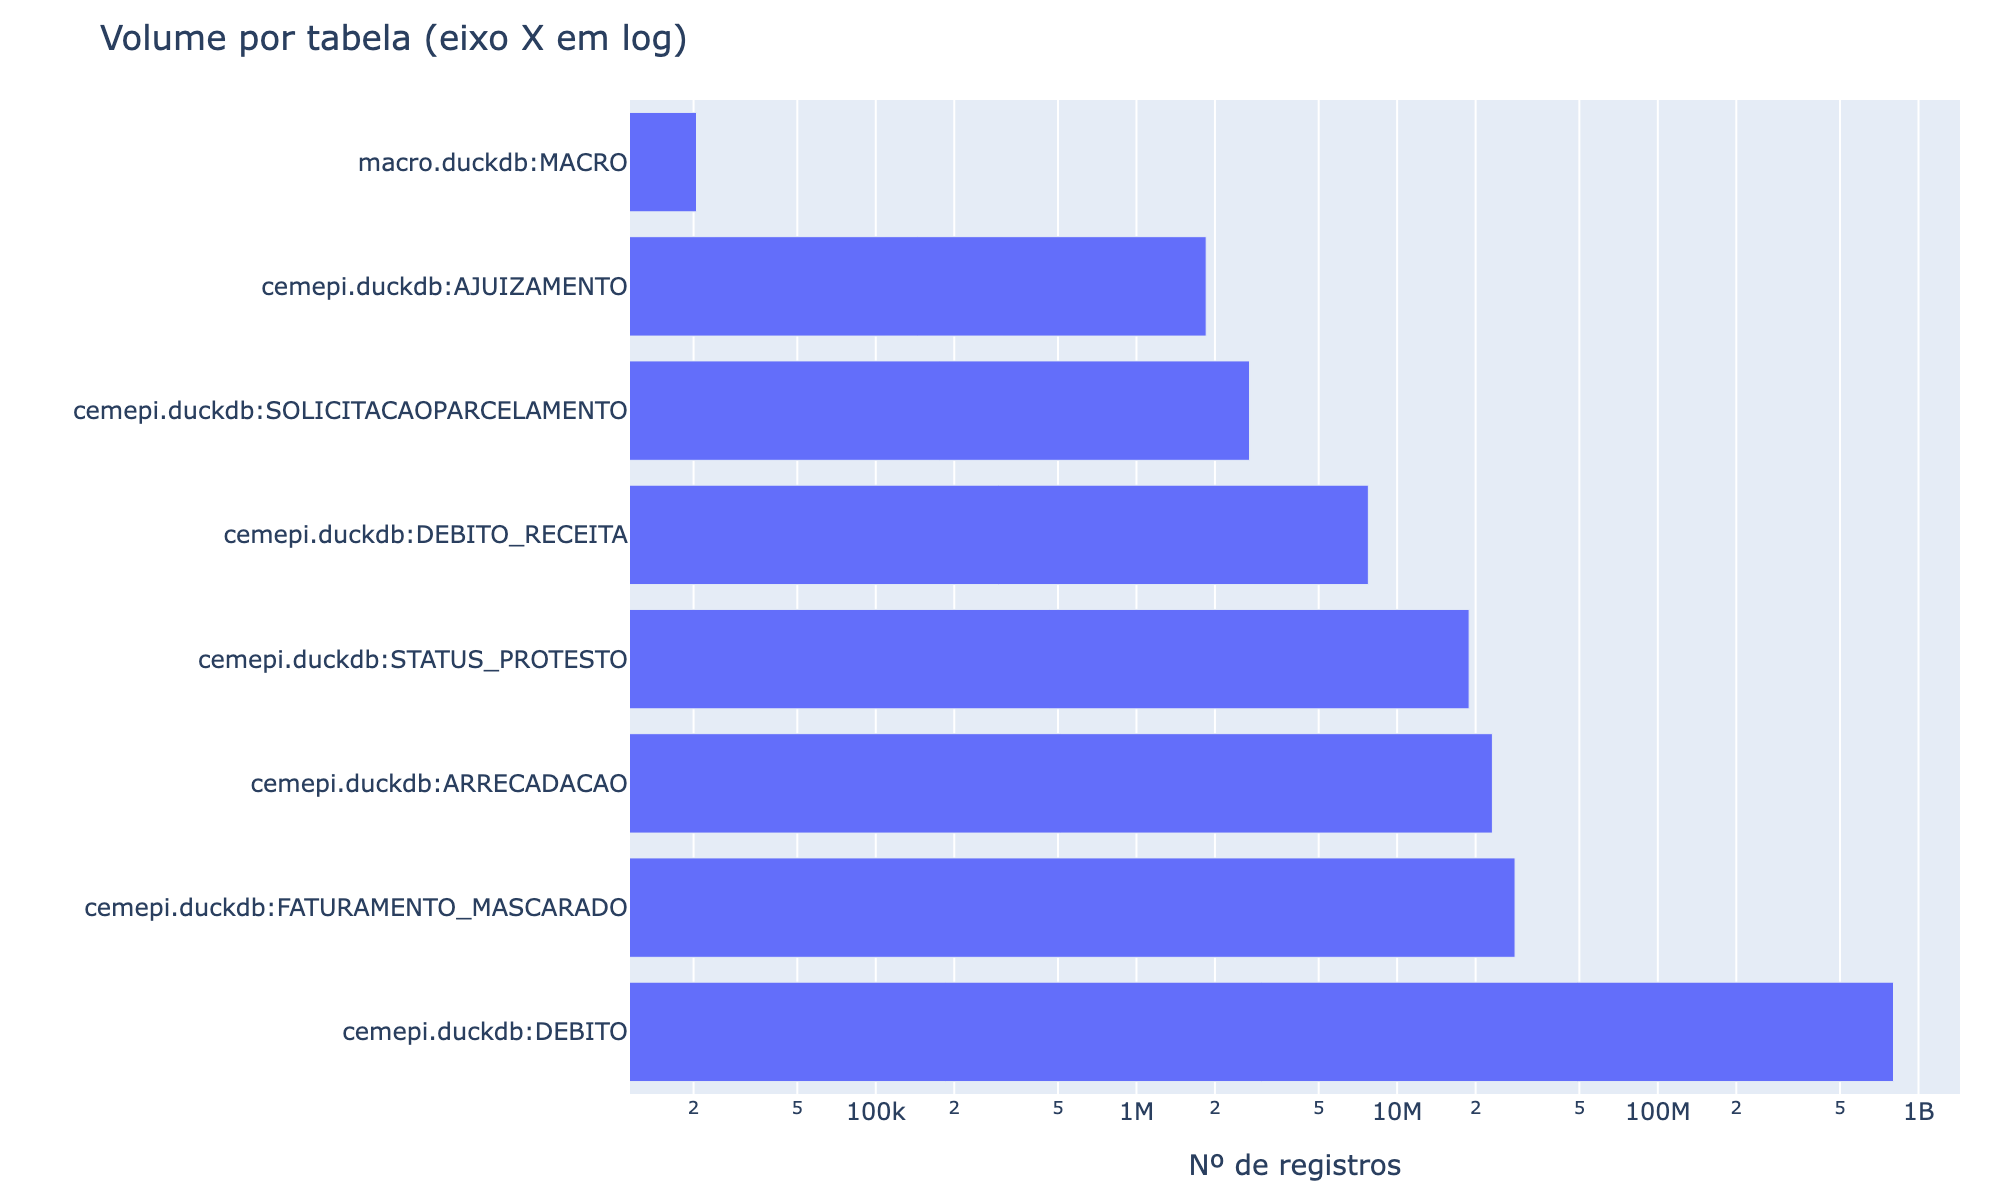

HTML → /Users/etorebraga/Code/cemepi-ctf-intel-fiscal/projects/macro/notebooks/eda_completo_artifacts/fig_volume_tabelas.html


In [14]:
# Barras: tamanho das tabelas (escala log se misturar MACRO e DEBITO)
plot_df = resumo.to_pandas() if False else resumo  # polars only
pdf = resumo.with_columns(pl.col("linhas").cast(pl.Float64))
fig = px.bar(
    pdf.to_dicts(),
    x="linhas",
    y="tabela",
    orientation="h",
    log_x=True,
    title="Volume por tabela (eixo X em log)",
    labels={"linhas": "Nº de registros", "tabela": ""},
)
fig.update_layout(height=max(320, 40 * len(pdf)), margin=dict(l=20, r=20, t=50, b=40))
fig.show()
fig.write_html(str(ARTIFACTS / "fig_volume_tabelas.html"))
print("HTML →", ARTIFACTS / "fig_volume_tabelas.html")


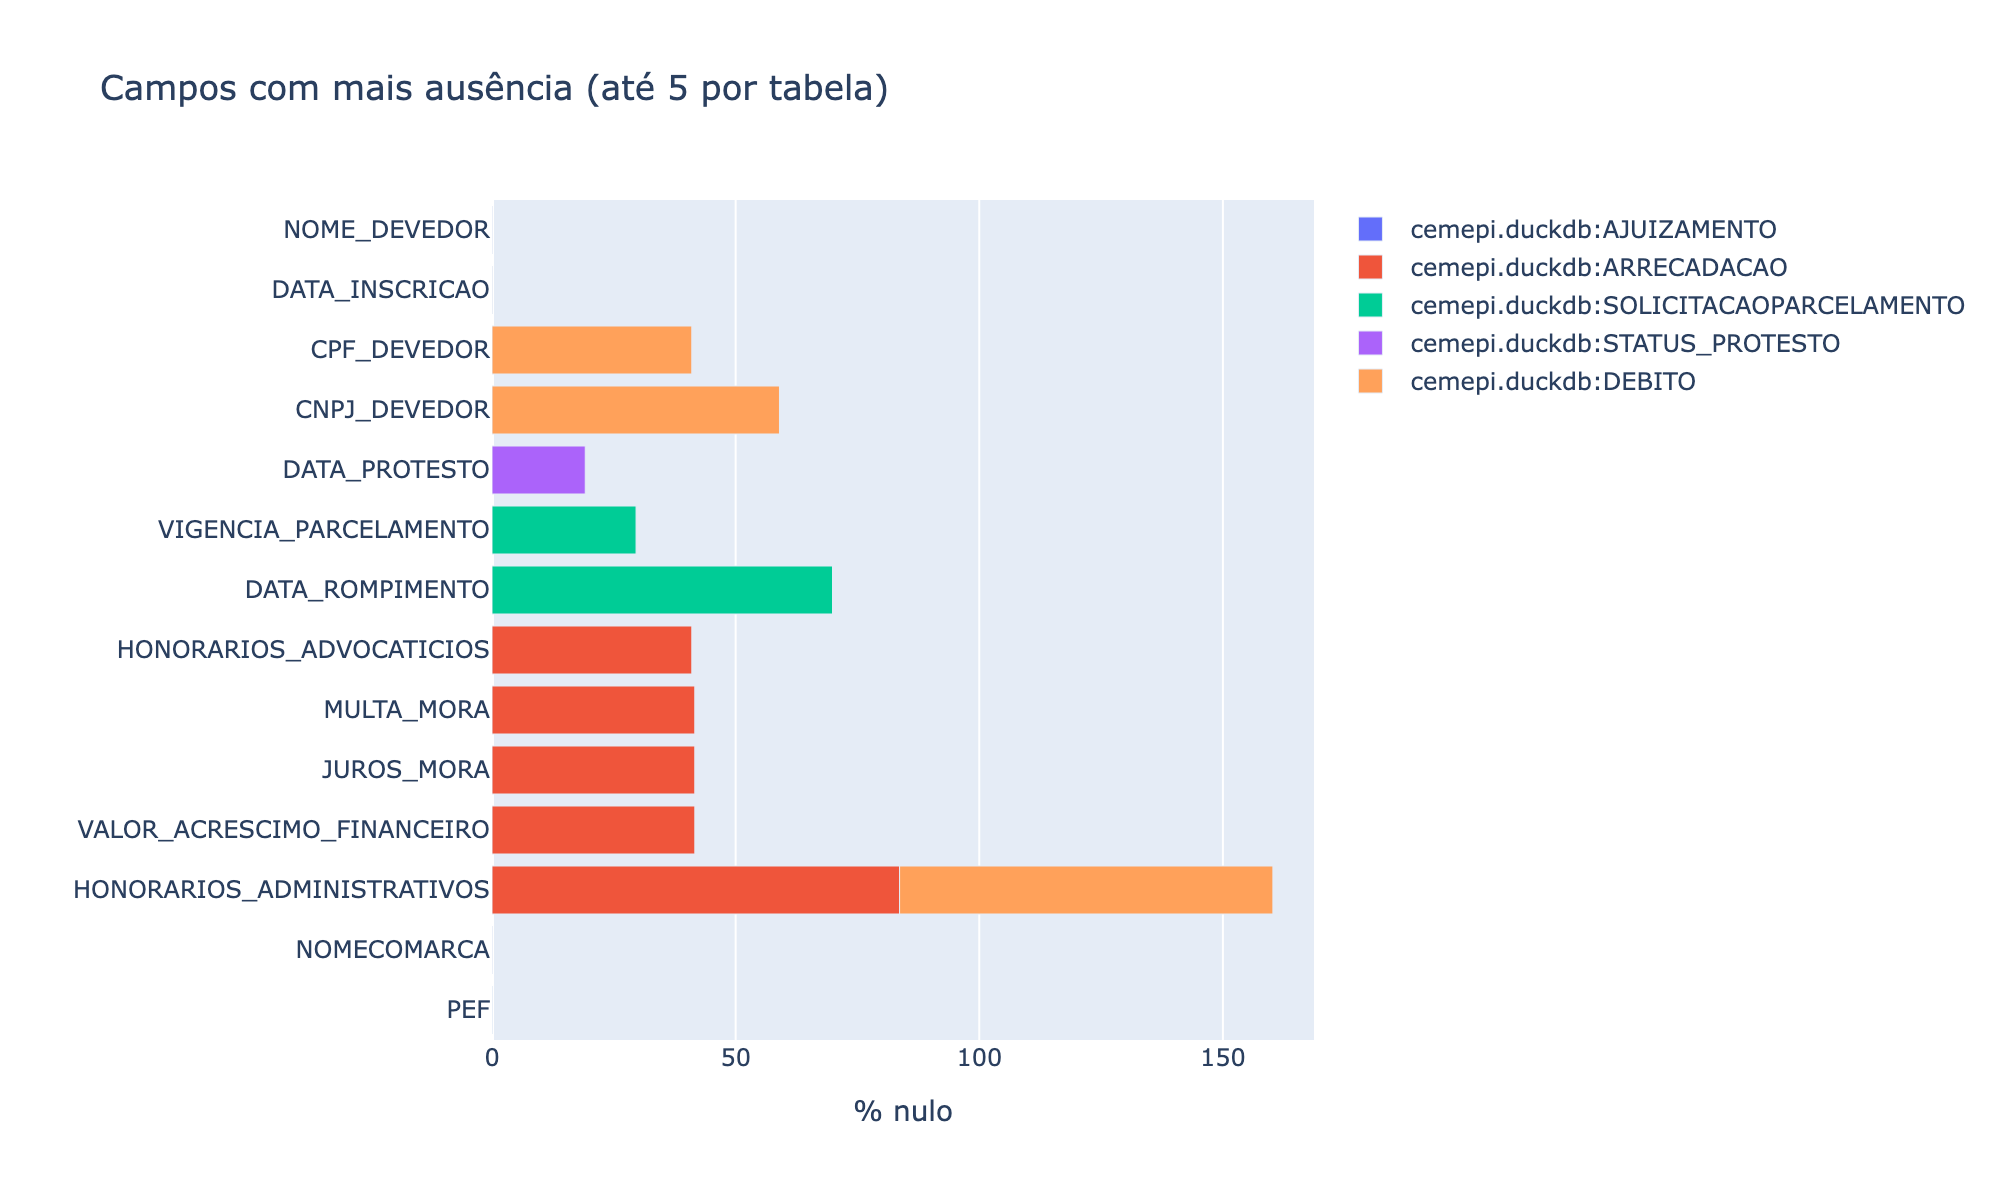

In [15]:
# Heat-ish: top nulos empilhados em texto já está no resumo; gráfico dos 5 maiores null por tabela inventariada
recs = []
for r in inv:
    for c, v in sorted((r.get("null_pct") or {}).items(), key=lambda x: -x[1])[:5]:
        if v <= 0:
            continue
        recs.append({"tabela": r["label"], "campo": c, "pct_nulo": 100 * v})
if not recs:
    print("sem nulos > 0 nas tabelas carregadas")
else:
    fig2 = px.bar(
        recs,
        x="pct_nulo",
        y="campo",
        color="tabela",
        orientation="h",
        title="Campos com mais ausência (até 5 por tabela)",
        labels={"pct_nulo": "% nulo", "campo": ""},
    )
    fig2.update_layout(height=max(360, 28 * len(recs)), legend_title_text="")
    fig2.show()
    fig2.write_html(str(ARTIFACTS / "fig_nulos_top.html"))


### Próximo (apresentação)

Sugestão lean pra professora: 1 slide “o que tem na base” (barra de volumes) + 1 “onde faltam dados” (nulos) + glossário das 3–4 tabelas que vamos usar no modelo (DEBITO, ARRECADACAO, macros). Etapa 2 (de-para ICMS/IPVA/TAXAS) alimenta o próximo bloco visual.


## 2. De-para `TIPO_DEBITO` → ICMS | IPVA | TAXAS

Uma agregação SQL em `cemepi.duckdb:DEBITO` (base completa). **Não** filtramos valor > 0.

**Cuidado:** cada linha é um recorte de extração (`ANO_EXTRACAO` × `MES_EXTRACAO`), não uma CDA única. Por isso o CSV traz `n_linhas`, `n_id` (IDs distintos) e `soma_valor` = soma de `VALOR_SEM_HONORARIOS` (estoque repetido entre meses — não some meses como se fosse fluxo).

**Regra (ordem):**
1. nome contém `IPVA` → IPVA
2. nome contém `ICMS` → ICMS
3. resto → TAXAS

A regra fica na coluna `regra` pra você revisar antes de cravar.

`n_id` usa `approx_count_distinct` (economia de RAM; erro típico <~2%). Temp DuckDB em `DATA_ROOT/_duckdb_tmp_eda`.


In [17]:
import duckdb
import polars as pl

assert fonte_ok
db = DATA_ROOT / "cemepi.duckdb"
assert db.is_file()

# Temp no HD Meedi + menos pressão de RAM
tmp = DATA_ROOT / "_duckdb_tmp_eda"
tmp.mkdir(exist_ok=True)

con = duckdb.connect()
con.execute(f"SET temp_directory='{tmp}'")
con.execute("SET max_temp_directory_size='50GiB'")
con.execute("SET memory_limit='4GB'")
con.execute("SET threads=2")
con.execute("SET preserve_insertion_order=false")
con.execute(f"ATTACH '{db}' AS cem (READ_ONLY)")

print("… agrega por tipo (approx distinct; temp no Meedi) …")
agg = con.execute(
    """
SELECT
  COALESCE(CAST(TIPO_DEBITO AS VARCHAR), '(nulo)') AS tipo_bruto,
  COUNT(*) AS n_linhas,
  approx_count_distinct(ID_DEBITO) AS n_id,
  SUM(VALOR_SEM_HONORARIOS) AS soma_valor
FROM cem.DEBITO
GROUP BY 1
ORDER BY n_linhas DESC
"""
).pl()
con.execute("DETACH cem")
con.close()
print(agg)


… agrega por tipo (approx distinct; temp no Meedi) …
shape: (140, 4)
┌─────────────────┬───────────┬──────────┬────────────┐
│ tipo_bruto      ┆ n_linhas  ┆ n_id     ┆ soma_valor │
│ ---             ┆ ---       ┆ ---      ┆ ---        │
│ str             ┆ i64       ┆ i64      ┆ f64        │
╞═════════════════╪═══════════╪══════════╪════════════╡
│ IPVA            ┆ 539367729 ┆ 24729670 ┆ 7.4179e11  │
│ ICMS Declarado  ┆ 207900434 ┆ 6072971  ┆ 1.1165e13  │
│ Taxa Judiciária ┆ 21925882  ┆ 989671   ┆ 6.6144e10  │
│ ICMS Autuação   ┆ 9805901   ┆ 178857   ┆ 3.1122e13  │
│ Multa Penal     ┆ 8283503   ┆ 135480   ┆ 1.5571e11  │
│ …               ┆ …         ┆ …        ┆ …          │
│ ICMS to         ┆ 1         ┆ 1        ┆ 1.2020e6   │
│ IPV             ┆ 1         ┆ 1        ┆ 6237.77    │
│ ICMS Declar     ┆ 1         ┆ 1        ┆ 31027.91   │
│ Multa Penalo    ┆ 1         ┆ 1        ┆ 23.63      │
│ IPIPVA          ┆ 1         ┆ 1        ┆ 1029.28    │
└─────────────────┴───────────┴────

In [18]:
def bucket_de(tipo: str) -> tuple[str, str]:
    t = (tipo or "").upper()
    if "IPVA" in t:
        return "IPVA", "contem IPVA"
    if "ICMS" in t:
        return "ICMS", "contem ICMS"
    return "TAXAS", "nem IPVA nem ICMS"

b = [bucket_de(t) for t in agg["tipo_bruto"].to_list()]
depara = agg.with_columns(
    pl.Series("bucket", [x[0] for x in b]),
    pl.Series("regra", [x[1] for x in b]),
).select("tipo_bruto", "bucket", "regra", "n_linhas", "n_id", "soma_valor")

out_dir = ARTIFACTS if "ARTIFACTS" in globals() else Path.cwd() / "eda_completo_artifacts"
out_dir.mkdir(exist_ok=True)
csv_path = out_dir / "tipo_debito_buckets.csv"
depara.write_csv(csv_path)
print(depara)
print("CSV →", csv_path)

tot = depara.group_by("bucket").agg(
    pl.col("n_linhas").sum(),
    pl.col("n_id").sum(),
    pl.col("soma_valor").sum(),
    pl.len().alias("n_tipos"),
).sort("soma_valor", descending=True)
print("\npor bucket:")
print(tot)


shape: (140, 6)
┌─────────────────┬────────┬───────────────────┬───────────┬──────────┬────────────┐
│ tipo_bruto      ┆ bucket ┆ regra             ┆ n_linhas  ┆ n_id     ┆ soma_valor │
│ ---             ┆ ---    ┆ ---               ┆ ---       ┆ ---      ┆ ---        │
│ str             ┆ str    ┆ str               ┆ i64       ┆ i64      ┆ f64        │
╞═════════════════╪════════╪═══════════════════╪═══════════╪══════════╪════════════╡
│ IPVA            ┆ IPVA   ┆ contem IPVA       ┆ 539367729 ┆ 24729670 ┆ 7.4179e11  │
│ ICMS Declarado  ┆ ICMS   ┆ contem ICMS       ┆ 207900434 ┆ 6072971  ┆ 1.1165e13  │
│ Taxa Judiciária ┆ TAXAS  ┆ nem IPVA nem ICMS ┆ 21925882  ┆ 989671   ┆ 6.6144e10  │
│ ICMS Autuação   ┆ ICMS   ┆ contem ICMS       ┆ 9805901   ┆ 178857   ┆ 3.1122e13  │
│ Multa Penal     ┆ TAXAS  ┆ nem IPVA nem ICMS ┆ 8283503   ┆ 135480   ┆ 1.5571e11  │
│ …               ┆ …      ┆ …                 ┆ …         ┆ …        ┆ …          │
│ ICMS to         ┆ ICMS   ┆ contem ICMS       ┆ 

### Como ler

`n_id` responde “quantos débitos distintos caem nesse tipo”. `soma_valor` é a soma do estoque **em todas as extrações** — serve pra ver o peso do tipo, não pra somar com arrecadação mensal.

Se algum rótulo importante cair em TAXAS por engano, a gente ajusta a regra na próxima célula (não reexecuta o GROUP BY).


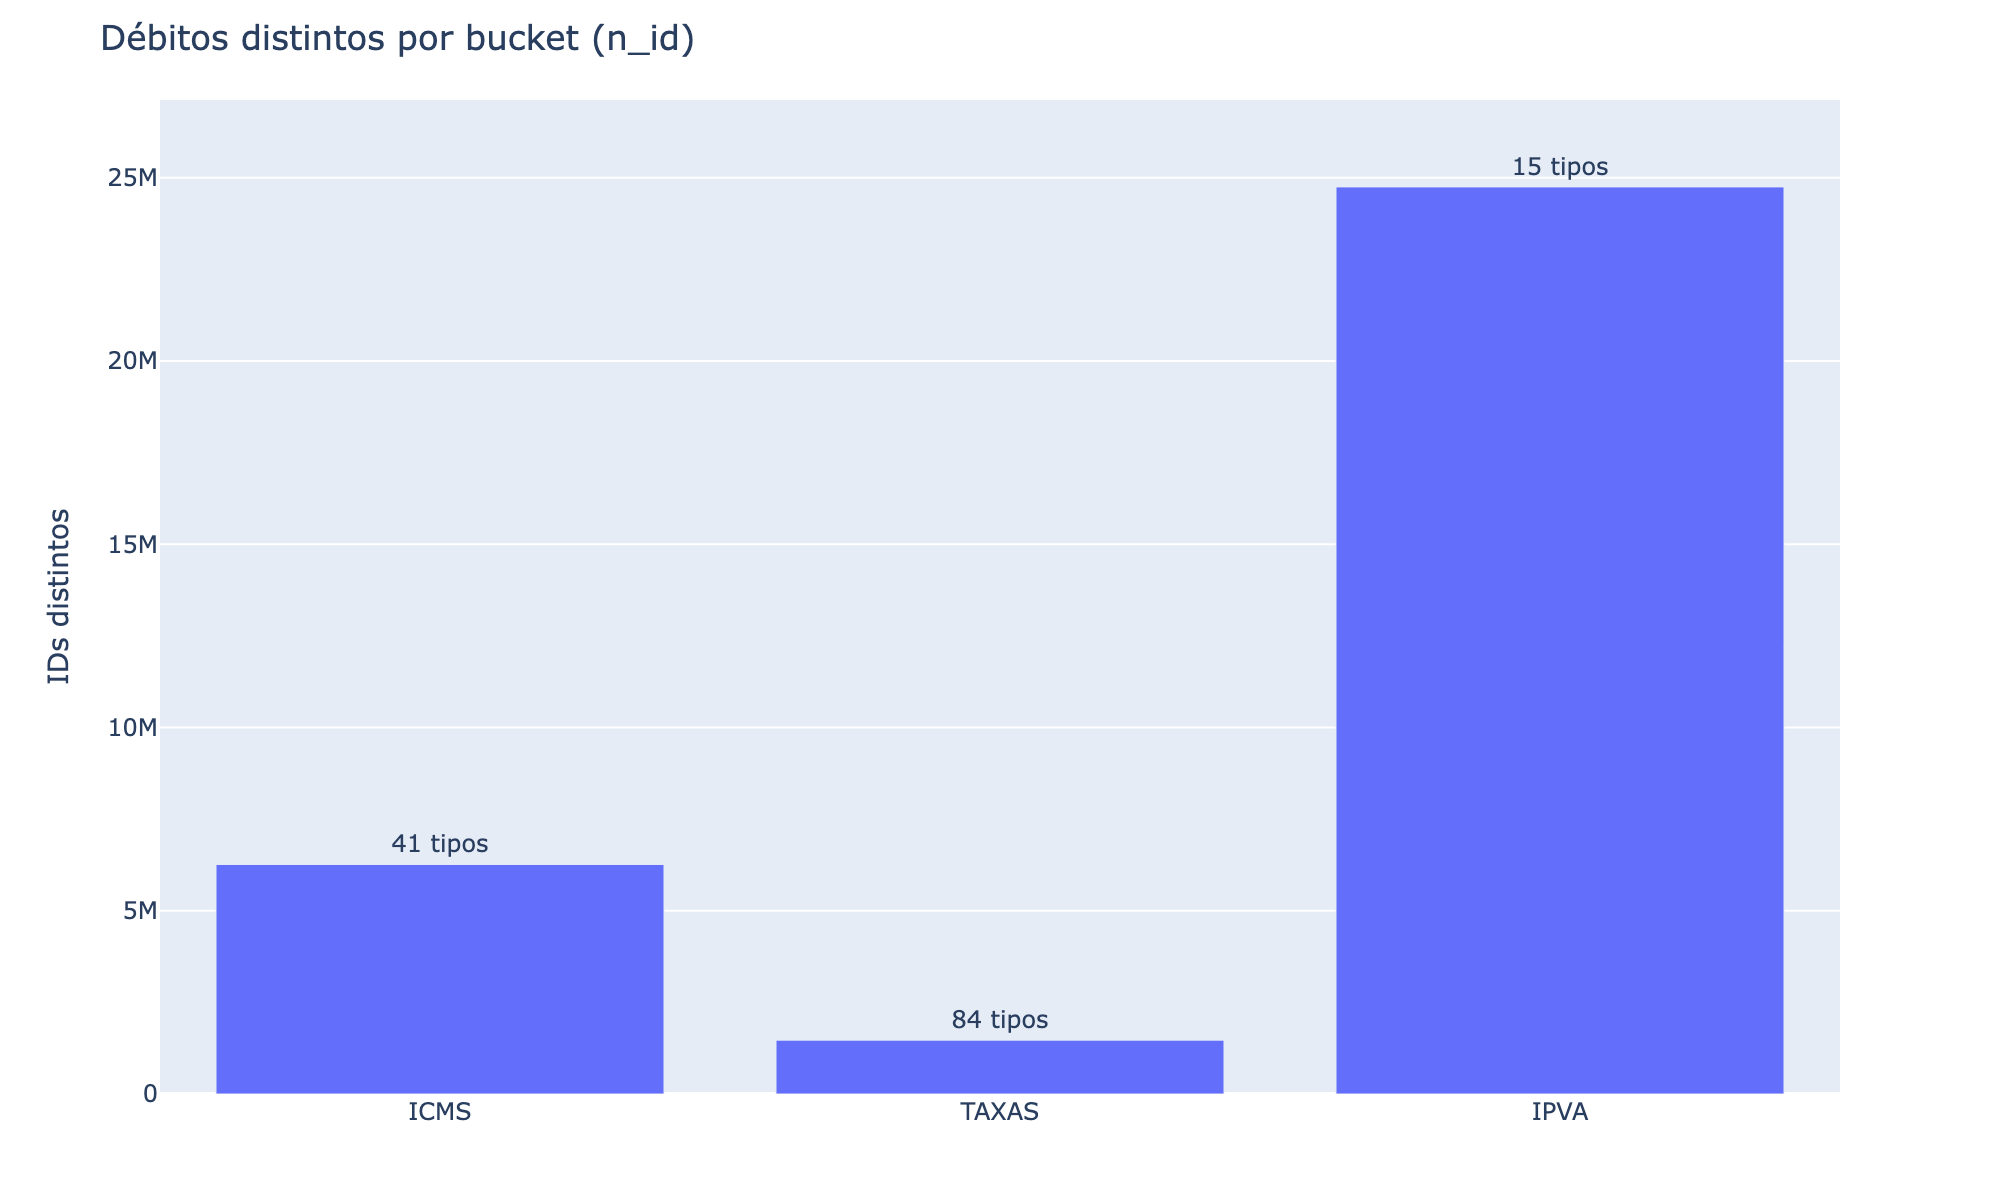

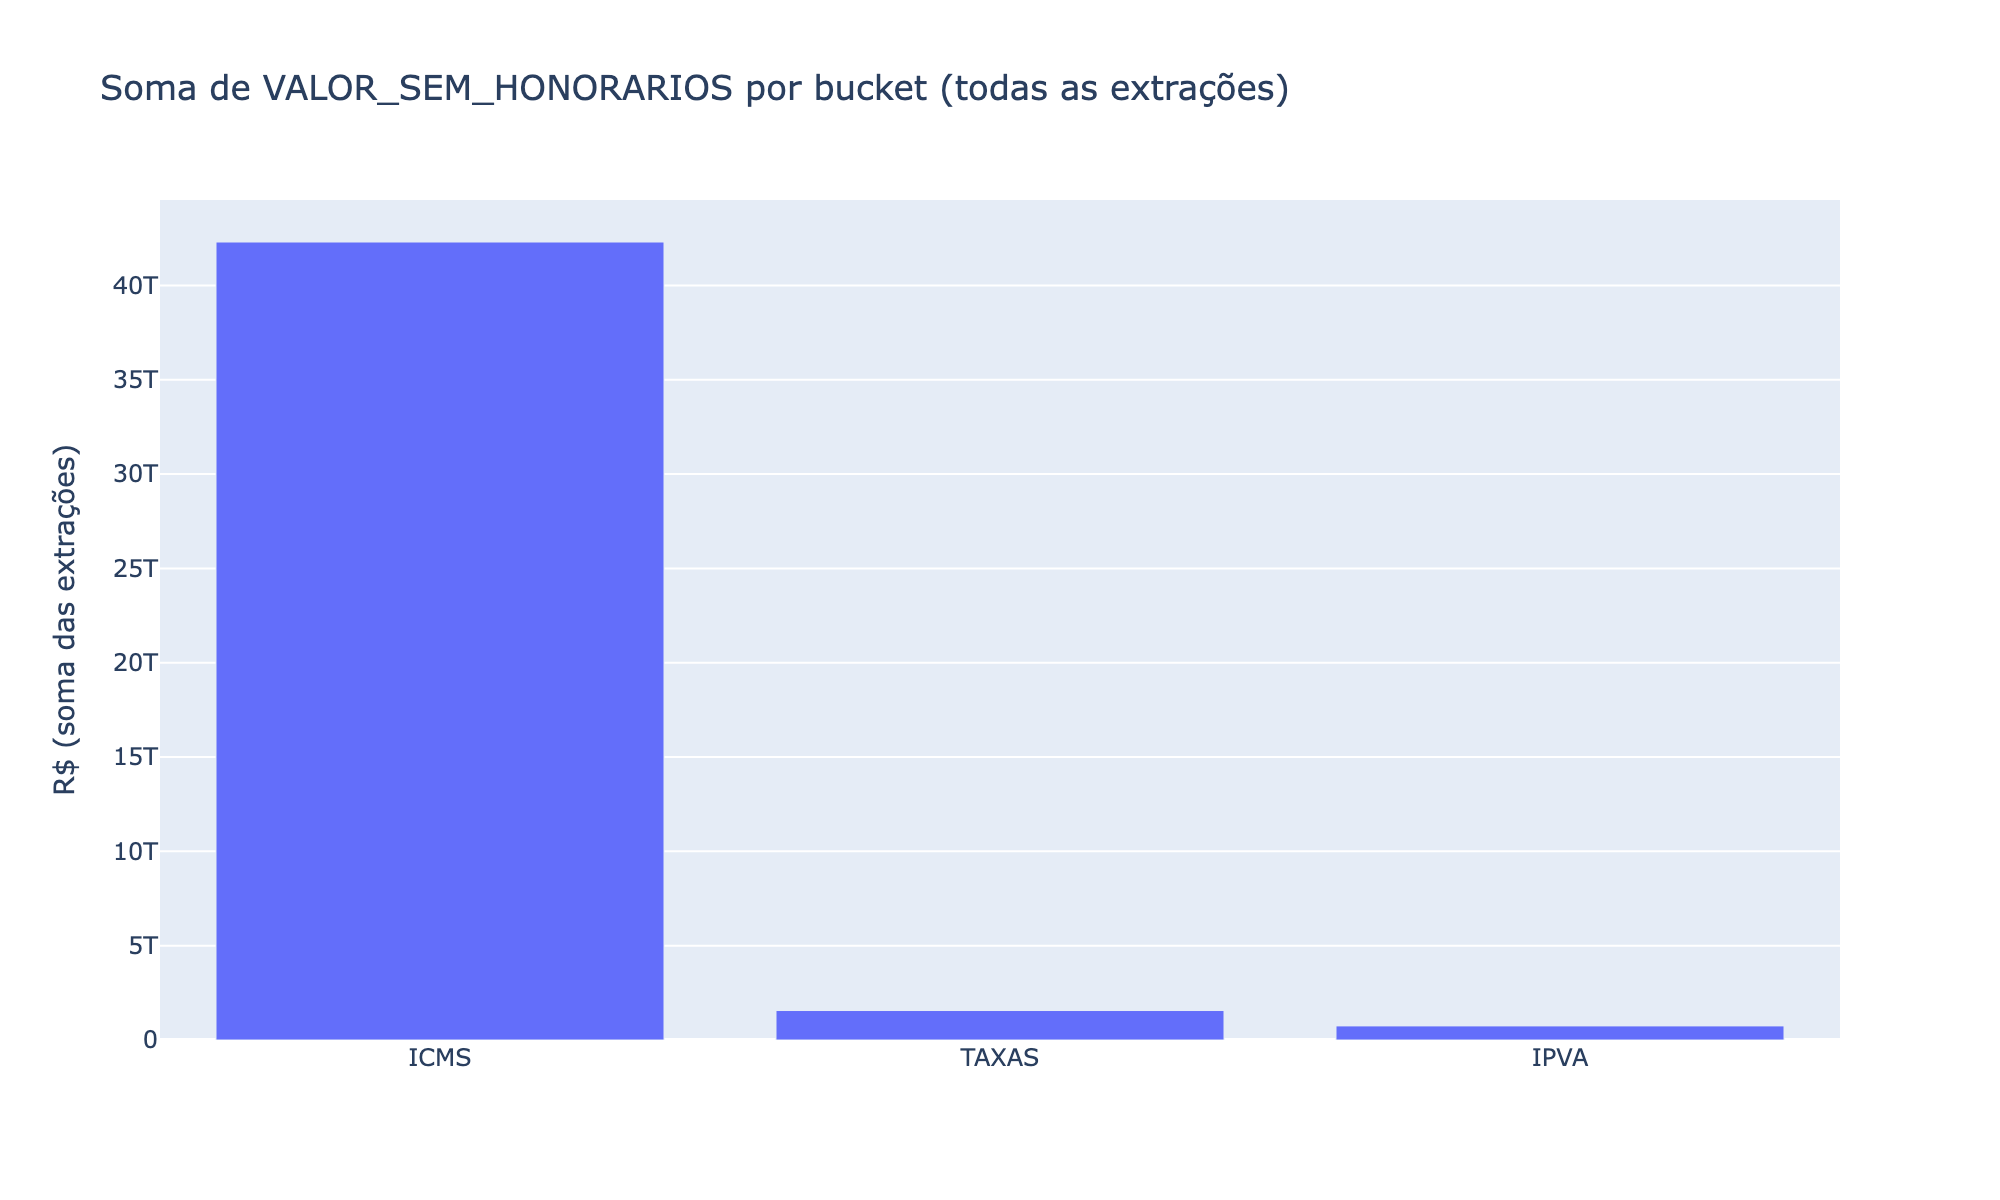

In [19]:
import plotly.express as px

fig = px.bar(
    tot.to_dicts(),
    x="bucket",
    y="n_id",
    text="n_tipos",
    title="Débitos distintos por bucket (n_id)",
    labels={"n_id": "IDs distintos", "bucket": ""},
)
fig.update_traces(texttemplate="%{text} tipos", textposition="outside")
fig.update_layout(margin=dict(t=50, b=40))
fig.show()

fig2 = px.bar(
    tot.to_dicts(),
    x="bucket",
    y="soma_valor",
    title="Soma de VALOR_SEM_HONORARIOS por bucket (todas as extrações)",
    labels={"soma_valor": "R$ (soma das extrações)", "bucket": ""},
)
fig2.show()
fig.write_html(str(out_dir / "fig_bucket_n_id.html"))
fig2.write_html(str(out_dir / "fig_bucket_valor.html"))


In [20]:
print("DoD etapa 2:", "PASS" if csv_path.is_file() and depara.height > 0 else "FAIL")
print("buckets:", sorted(depara["bucket"].unique().to_list()))


DoD etapa 2: PASS
buckets: ['ICMS', 'IPVA', 'TAXAS']


## 3. Descritiva — ICMS | IPVA | TAXAS

Usa o CSV da etapa 2 (`tipo_debito_buckets.csv`). Contraste pedido: **IPVA em quantidade** vs **ICMS em valor**.

Idade da CDA: `idade_anos = (hoje − DATA_INSCRICAO)/365.25`, média e mediana por bucket (base completa, mesma regra).


In [21]:
from datetime import date
import duckdb
import plotly.express as px
import polars as pl

assert fonte_ok
csv_path = (ARTIFACTS if "ARTIFACTS" in globals() else Path.cwd() / "eda_completo_artifacts") / "tipo_debito_buckets.csv"
assert csv_path.is_file(), "Rode a etapa 2 antes."
depara = pl.read_csv(csv_path)

por_bucket = depara.group_by("bucket").agg(
    pl.col("n_linhas").sum(),
    pl.col("n_id").sum(),
    pl.col("soma_valor").sum(),
).with_columns(
    (pl.col("n_id") / pl.col("n_id").sum() * 100).alias("pct_qtd"),
    (pl.col("soma_valor") / pl.col("soma_valor").sum() * 100).alias("pct_valor"),
).sort("bucket")
print(por_bucket)


shape: (3, 6)
┌────────┬───────────┬──────────┬────────────┬───────────┬───────────┐
│ bucket ┆ n_linhas  ┆ n_id     ┆ soma_valor ┆ pct_qtd   ┆ pct_valor │
│ ---    ┆ ---       ┆ ---      ┆ ---        ┆ ---       ┆ ---       │
│ str    ┆ i64       ┆ i64      ┆ f64        ┆ f64       ┆ f64       │
╞════════╪═══════════╪══════════╪════════════╪═══════════╪═══════════╡
│ ICMS   ┆ 217876730 ┆ 6263761  ┆ 4.2304e13  ┆ 19.282896 ┆ 94.821223 │
│ IPVA   ┆ 540016544 ┆ 24750260 ┆ 7.4743e11  ┆ 76.19331  ┆ 1.675336  │
│ TAXAS  ┆ 43951644  ┆ 1469487  ┆ 1.5630e12  ┆ 4.523794  ┆ 3.503442  │
└────────┴───────────┴──────────┴────────────┴───────────┴───────────┘


### Como ler % quantidade vs % valor

Se IPVA tiver `pct_qtd` alto e `pct_valor` baixo, há muitos débitos “baratos”. ICMS com o inverso justifica focar o painel/modelos no ICMS.


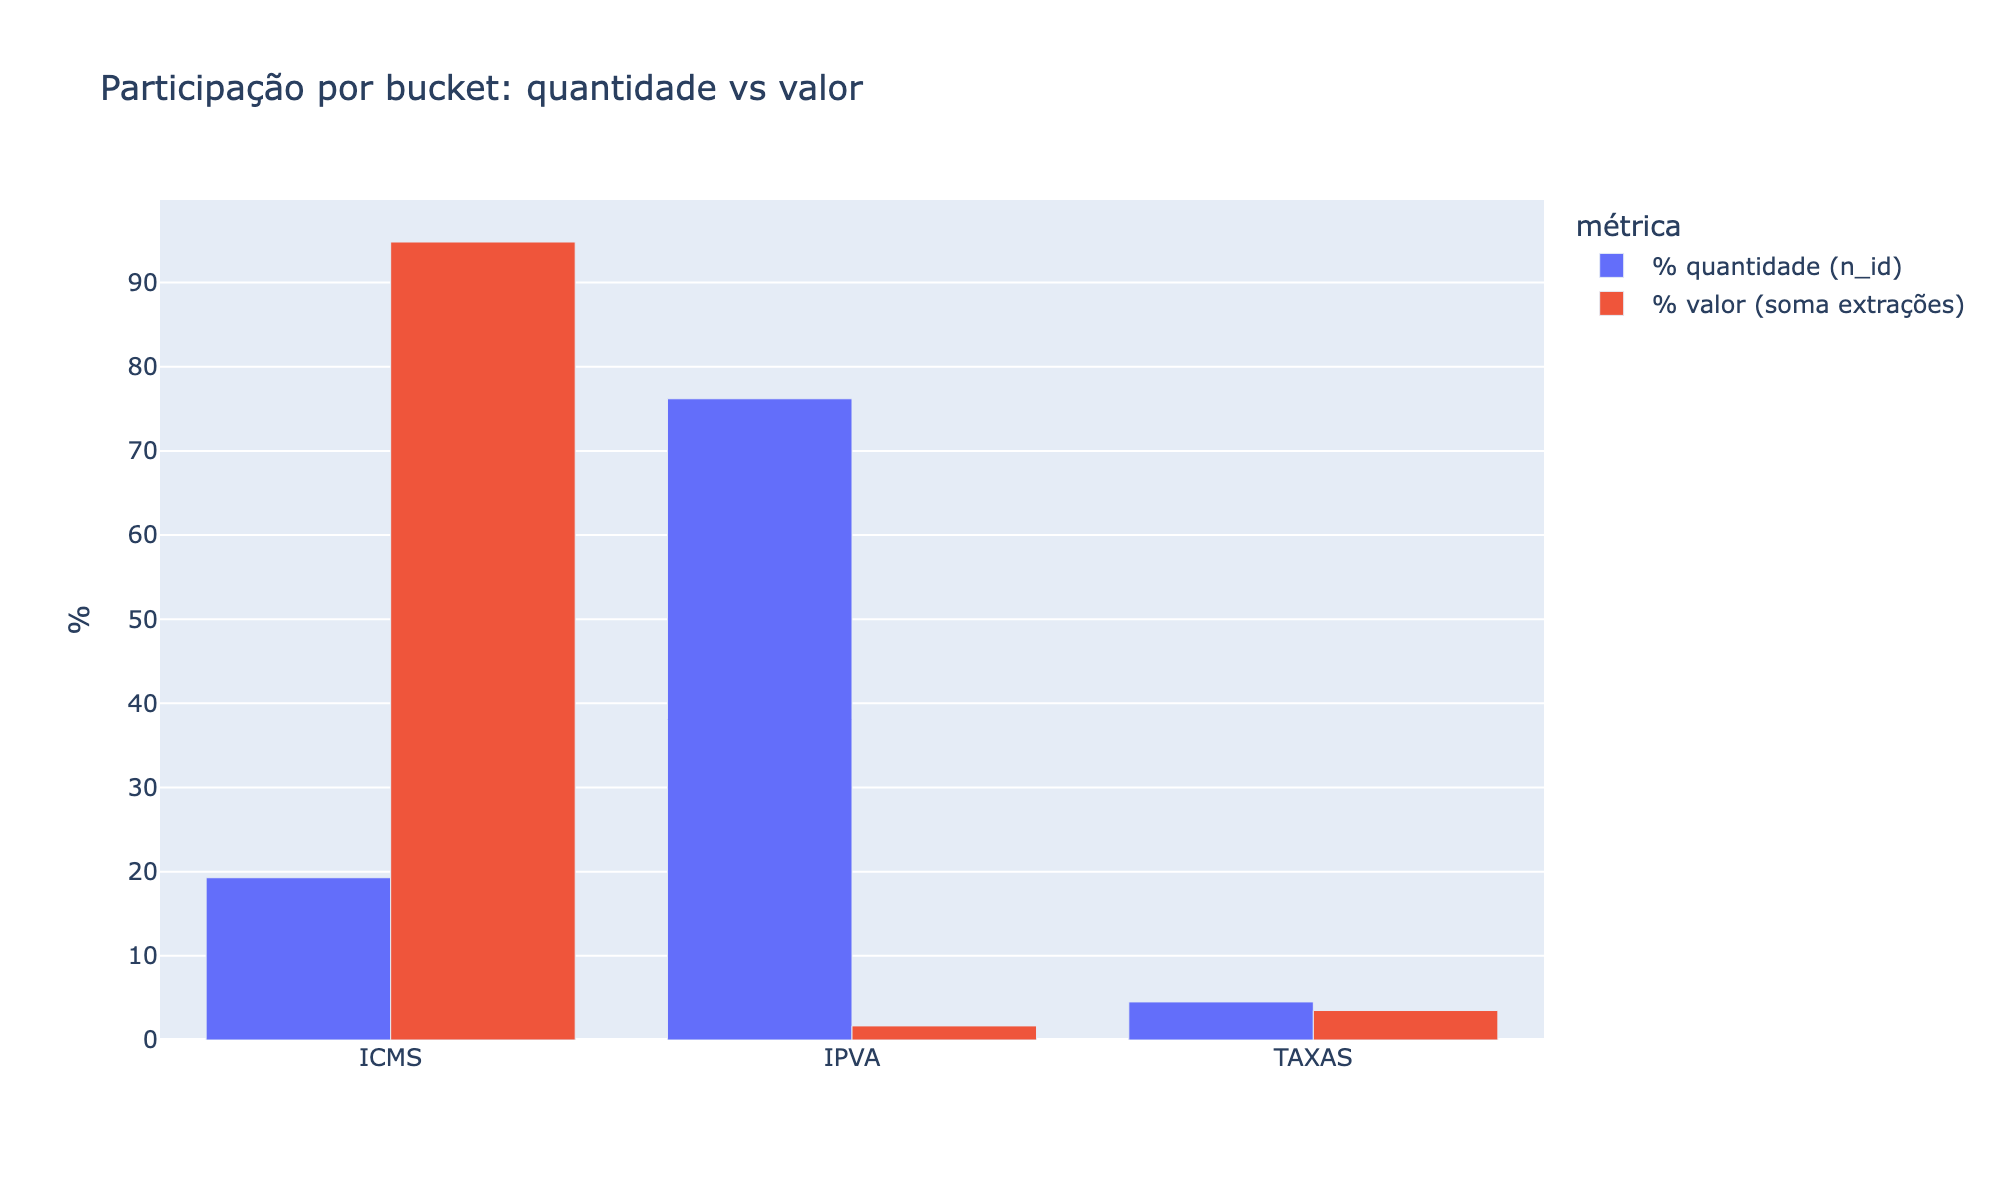

In [22]:
long = pl.concat([
    por_bucket.select("bucket", pl.col("pct_qtd").alias("pct")).with_columns(pl.lit("% quantidade (n_id)").alias("métrica")),
    por_bucket.select("bucket", pl.col("pct_valor").alias("pct")).with_columns(pl.lit("% valor (soma extrações)").alias("métrica")),
])
fig = px.bar(
    long.to_dicts(),
    x="bucket",
    y="pct",
    color="métrica",
    barmode="group",
    title="Participação por bucket: quantidade vs valor",
    labels={"pct": "%", "bucket": ""},
)
fig.show()
out = csv_path.parent
fig.write_html(str(out / "fig_bucket_pct_qtd_valor.html"))


In [6]:
# Idade CDA por bucket — leve: AVG + approx_quantile (sem MEDIAN exato)
db = DATA_ROOT / "cemepi.duckdb"
tmp = DATA_ROOT / "_duckdb_tmp_eda"
tmp.mkdir(exist_ok=True)
con = duckdb.connect()
con.execute(f"SET temp_directory='{tmp}'")
con.execute("SET max_temp_directory_size='80GiB'")
con.execute("SET memory_limit='2GB'")
con.execute("SET threads=1")
con.execute("SET preserve_insertion_order=false")
con.execute(f"ATTACH '{db}' AS cem (READ_ONLY)")
print("… idade por bucket (AVG + approx mediana) …")
sql_idade = """
SELECT
  CASE
    WHEN UPPER(CAST(TIPO_DEBITO AS VARCHAR)) LIKE '%IPVA%' THEN 'IPVA'
    WHEN UPPER(CAST(TIPO_DEBITO AS VARCHAR)) LIKE '%ICMS%' THEN 'ICMS'
    ELSE 'TAXAS'
  END AS bucket,
  COUNT(*) AS n_linhas,
  COUNT(TRY_CAST(DATA_INSCRICAO AS DATE)) AS n_com_data_valida,
  AVG(date_diff('day', TRY_CAST(DATA_INSCRICAO AS DATE), CURRENT_DATE) / 365.25)
    FILTER (WHERE TRY_CAST(DATA_INSCRICAO AS DATE) IS NOT NULL) AS idade_media_anos,
  approx_quantile(
    date_diff('day', TRY_CAST(DATA_INSCRICAO AS DATE), CURRENT_DATE) / 365.25,
    0.5
  ) FILTER (WHERE TRY_CAST(DATA_INSCRICAO AS DATE) IS NOT NULL) AS idade_mediana_anos
FROM cem.DEBITO
GROUP BY 1
ORDER BY 1
"""
idade = con.execute(sql_idade).pl()
con.execute("DETACH cem")
con.close()
print(idade)
out = ARTIFACTS if "ARTIFACTS" in globals() else Path.cwd() / "eda_completo_artifacts"
out.mkdir(exist_ok=True)
idade.write_csv(out / "idade_cda_por_bucket.csv")
print("CSV →", out / "idade_cda_por_bucket.csv")


… idade por bucket (AVG + approx mediana) …
shape: (3, 5)
┌────────┬───────────┬───────────────────┬──────────────────┬────────────────────┐
│ bucket ┆ n_linhas  ┆ n_com_data_valida ┆ idade_media_anos ┆ idade_mediana_anos │
│ ---    ┆ ---       ┆ ---               ┆ ---              ┆ ---                │
│ str    ┆ i64       ┆ i64               ┆ f64              ┆ f64                │
╞════════╪═══════════╪═══════════════════╪══════════════════╪════════════════════╡
│ ICMS   ┆ 217876730 ┆ 217876674         ┆ 11.870167        ┆ 10.477813          │
│ IPVA   ┆ 540016544 ┆ 540016419         ┆ 7.619893         ┆ 7.801065           │
│ TAXAS  ┆ 43951644  ┆ 43893901          ┆ 8.268612         ┆ 6.682461           │
└────────┴───────────┴───────────────────┴──────────────────┴────────────────────┘
CSV → /Users/etorebraga/Code/cemepi-ctf-intel-fiscal/projects/macro/notebooks/eda_completo_artifacts/idade_cda_por_bucket.csv


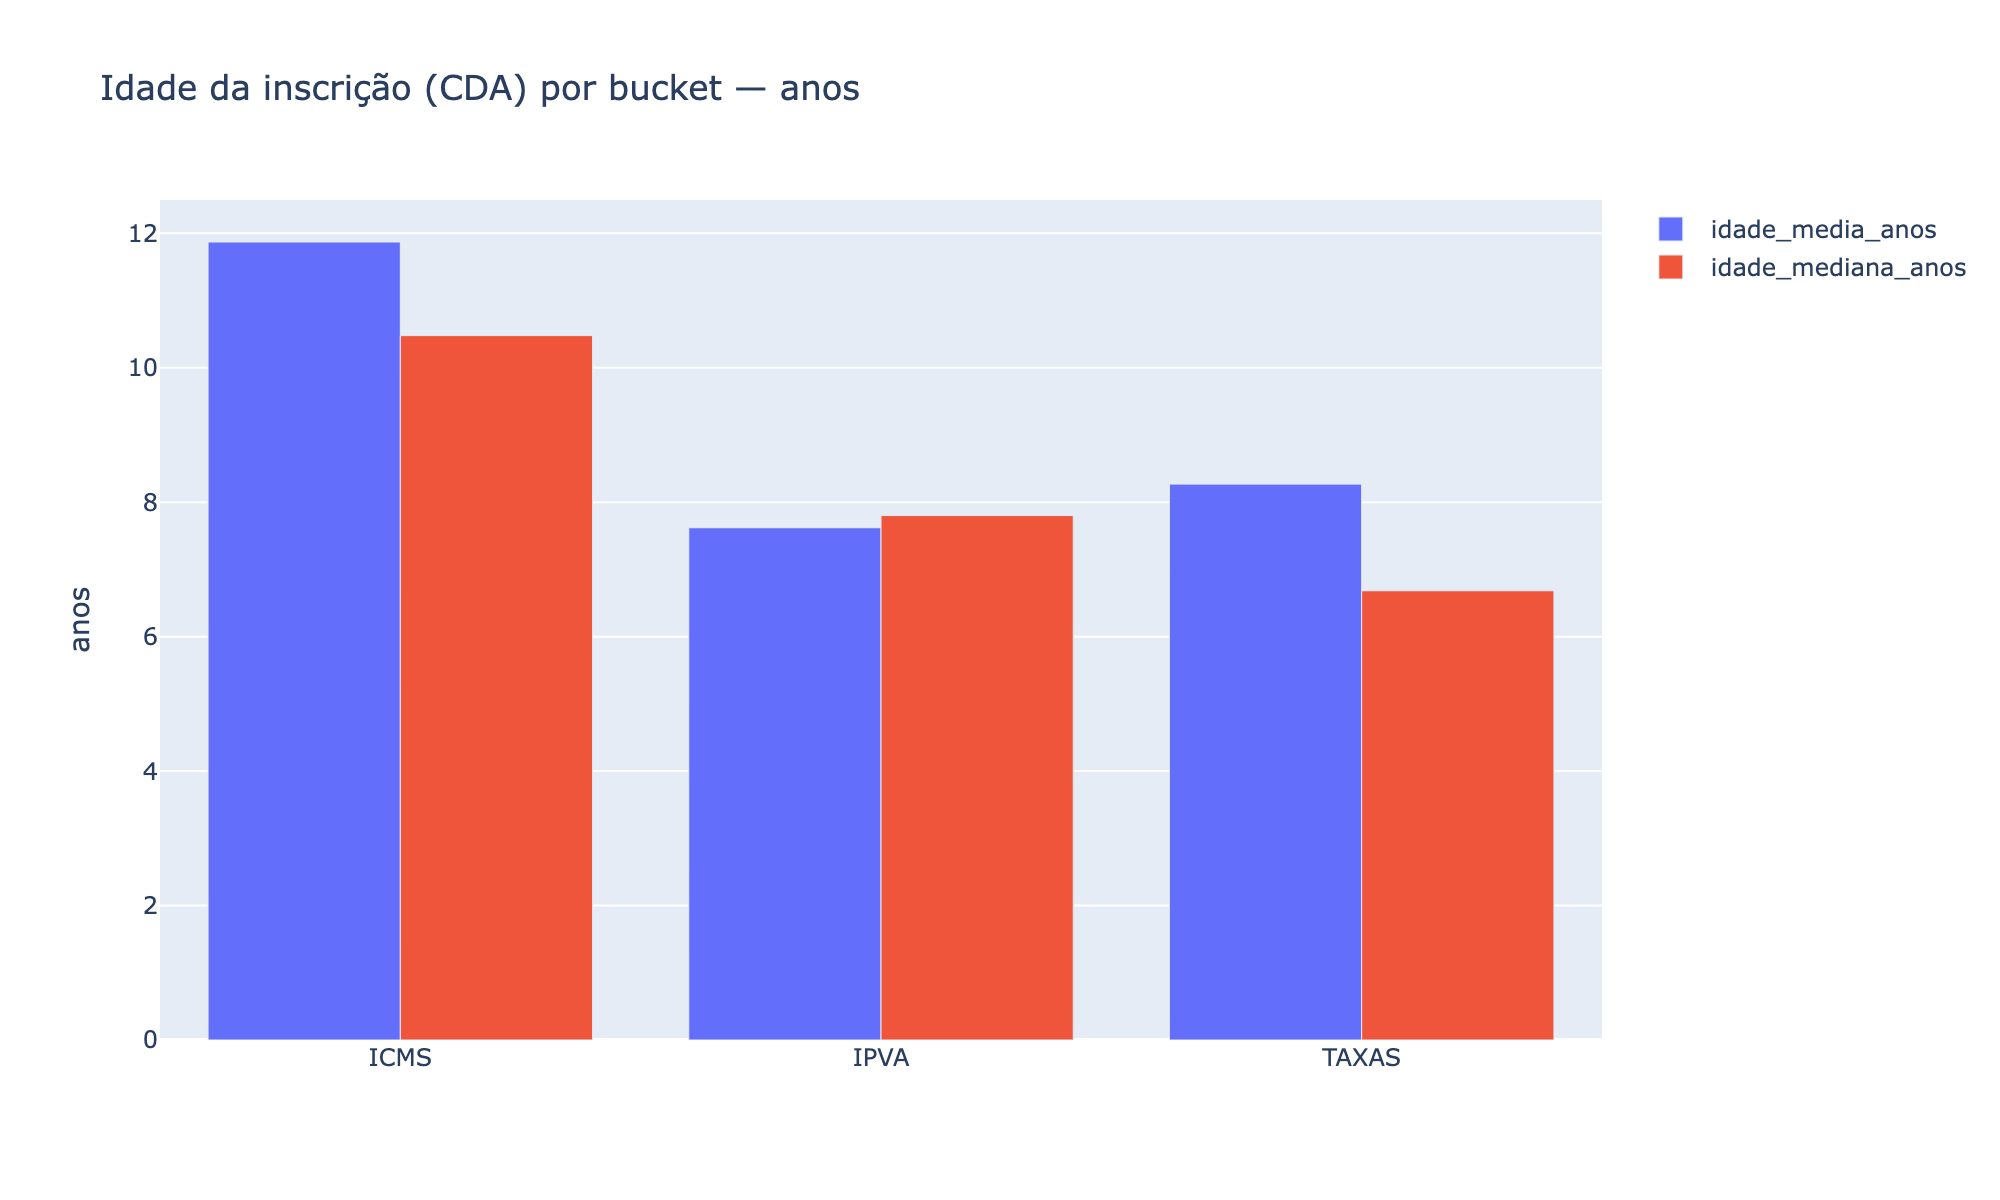

DoD etapa 3: PASS | idade True | depara csv True


In [11]:
out = ARTIFACTS if "ARTIFACTS" in globals() else Path.cwd() / "eda_completo_artifacts"
fig_i = px.bar(
    idade.to_dicts(),
    x="bucket",
    y=["idade_media_anos", "idade_mediana_anos"],
    barmode="group",
    title="Idade da inscrição (CDA) por bucket — anos",
    labels={"value": "anos", "bucket": "", "variable": ""},
)
fig_i.show()
fig_i.write_html(str(out / "fig_idade_cda_bucket.html"))
ok_idade = "idade" in globals() and idade.height >= 1
csv_b = out / "tipo_debito_buckets.csv"
ok_depara = csv_b.is_file()
print("DoD etapa 3:", "PASS" if ok_idade and ok_depara else "parcial", "| idade", ok_idade, "| depara csv", ok_depara)


## 4. Painel ICMS — base completa

Todos os débitos com tipo ICMS. **Sem amostra. Sem filtrar taxa/arrecadação > 0.**

Uma passada SQL: estoque médio por `ID_DEBITO × ANO_EXTRACAO`, left join com arrecadação anual (só IDs ICMS), `taxa = arrec/estoque` (0 quando não há GARE).

Memória: temp no Meedi, `threads=2`, `memory_limit=3GB`, `preserve_insertion_order=false`. Se o parquet já existir, a célula **pula** o COPY.


In [ ]:
import duckdb
import polars as pl
import plotly.express as px

assert fonte_ok
out = ARTIFACTS if "ARTIFACTS" in globals() else Path.cwd() / "eda_completo_artifacts"
out.mkdir(exist_ok=True)
db = DATA_ROOT / "cemepi.duckdb"
tmp = DATA_ROOT / "_duckdb_tmp_eda"
tmp.mkdir(exist_ok=True)
painel_path = out / "painel_icms_completo.parquet"

if painel_path.is_file() and painel_path.stat().st_size > 0:
    print("SKIP COPY — já existe:", painel_path, f"({painel_path.stat().st_size/1e6:.0f} MB)")
else:
    con = duckdb.connect()
    con.execute(f"SET temp_directory='{tmp}'")
    con.execute("SET max_temp_directory_size='100GiB'")
    con.execute("SET memory_limit='3GB'")
    con.execute("SET threads=2")
    con.execute("SET preserve_insertion_order=false")
    con.execute(f"ATTACH '{db}' AS cem (READ_ONLY)")
    print("… COPY painel ICMS completo → parquet (pode demorar bastante) …")
    sql = f"""
    COPY (
      WITH estoque AS (
        SELECT
          ID_DEBITO,
          ANO_EXTRACAO AS ano,
          AVG(VALOR_SEM_HONORARIOS) AS estoque_medio,
          MAX(TRY_CAST(DATA_INSCRICAO AS DATE)) AS data_inscricao
        FROM cem.DEBITO
        WHERE UPPER(CAST(TIPO_DEBITO AS VARCHAR)) LIKE '%ICMS%'
          AND ANO_EXTRACAO BETWEEN 1990 AND 2030
        GROUP BY 1, 2
      ),
      ids_icms AS (
        SELECT DISTINCT ID_DEBITO FROM estoque
      ),
      arrec AS (
        SELECT
          a.ID_DEBITO,
          a.ANO AS ano,
          SUM(COALESCE(a.VALOR_RECEITA, 0)) AS arrecadado
        FROM cem.ARRECADACAO a
        SEMI JOIN ids_icms i USING (ID_DEBITO)
        GROUP BY 1, 2
      )
      SELECT
        e.ID_DEBITO,
        e.ano,
        e.estoque_medio,
        e.data_inscricao,
        COALESCE(a.arrecadado, 0) AS arrecadado,
        CASE
          WHEN e.estoque_medio > 0 THEN COALESCE(a.arrecadado, 0) / e.estoque_medio
          ELSE NULL
        END AS taxa
      FROM estoque e
      LEFT JOIN arrec a USING (ID_DEBITO, ano)
    ) TO '{painel_path}' (FORMAT PARQUET)
    """
    con.execute(sql)
    con.execute("DETACH cem")
    con.close()
    print("parquet →", painel_path)



linhas painel=23,230,975  anos 2016→2026  share taxa==0=0.918


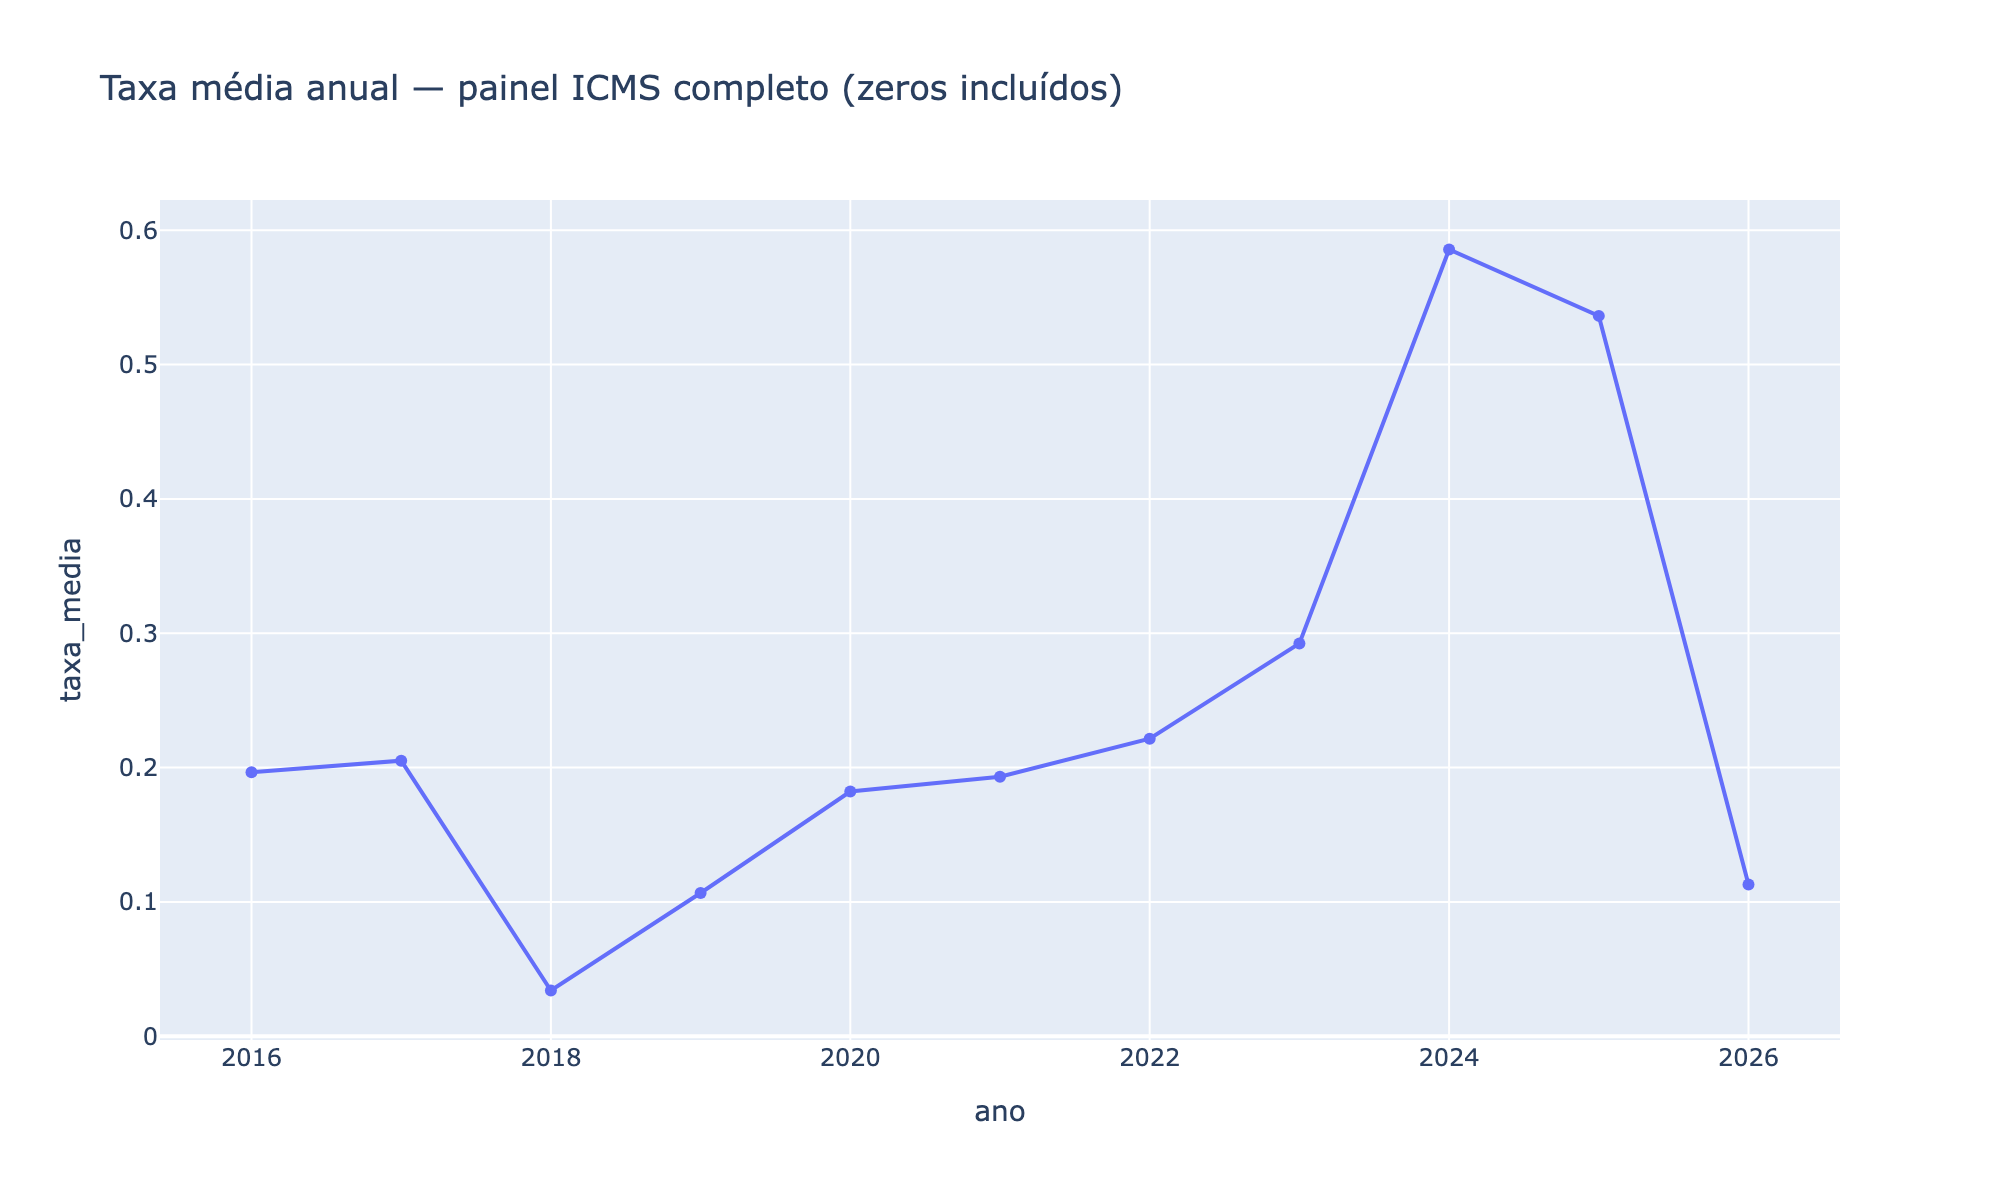

DoD etapa 4: PASS


In [15]:
# Resumo leve via scan (não carrega o parquet inteiro na RAM)
lf = pl.scan_parquet(str(painel_path))
n = lf.select(pl.len()).collect().item()
anos = lf.select(pl.col("ano").min().alias("lo"), pl.col("ano").max().alias("hi")).collect()
share0 = lf.select((pl.col("taxa") == 0).mean()).collect().item()
print(f"linhas painel={n:,}  anos {anos['lo'][0]}→{anos['hi'][0]}  share taxa==0={share0:.3f}")
agg_ano = (
    lf.group_by("ano")
    .agg(pl.col("taxa").mean().alias("taxa_media"), pl.len().alias("n"))
    .sort("ano")
    .collect()
)
fig = px.line(agg_ano.to_dicts(), x="ano", y="taxa_media", markers=True,
              title="Taxa média anual — painel ICMS completo (zeros incluídos)")
fig.show()
fig.write_html(str(out / "fig_painel_taxa_media_ano.html"))
print("DoD etapa 4:", "PASS" if painel_path.is_file() and n > 0 else "FAIL")


## 5. Correlações e lags 1–3 (painel ICMS)

A partir do parquet da etapa 4: idade da CDA, lags anuais da taxa (1–3) **dentro de cada** `ID_DEBITO`, correlações de Pearson e Spearman, e um heatmap.

Memória: DuckDB no parquet (sem carregar 23M linhas no Python), temp Meedi, `threads=2` / `3GB`.


### O que é Pearson / Spearman / lag (e como usamos aqui)

**Correlação de Pearson** mede associação *linear* entre duas variáveis contínuas (valores de −1 a +1). Aqui: relação linear entre `taxa`, estoque, idade e lags da própria taxa.

**Spearman** é o Pearson dos *postos* (ranks): captura associação monótona (não só linear). Útil se outliers de taxa distorcem a correlação linear.

**Lag k** de uma série no painel: valor da mesma unidade *k* períodos atrás. Com partição por `ID_DEBITO` e ordem por `ano`, `taxa_l1` / `taxa_l2` / `taxa_l3` são a taxa do mesmo débito 1, 2 ou 3 anos antes.

Lags 1–3 testam persistência da arrecadação relativa ao estoque (a taxa “de ontem” prevê a de hoje?).

Referências clássicas: Spearman (1904); definição de autocorrelação em painéis em Wooldridge, *Econometric Analysis of Cross Section and Panel Data*.


In [16]:
import duckdb
from pathlib import Path
import polars as pl
import plotly.express as px

assert fonte_ok
out = ARTIFACTS if "ARTIFACTS" in globals() else Path.cwd() / "eda_completo_artifacts"
painel_path = out / "painel_icms_completo.parquet"
assert painel_path.is_file(), "rode a etapa 4 antes"
lags_path = out / "painel_icms_com_lags.parquet"
corr_path = out / "corr_lags_icms.csv"
tmp = DATA_ROOT / "_duckdb_tmp_eda"
tmp.mkdir(exist_ok=True)

con = duckdb.connect()
con.execute(f"SET temp_directory='{tmp}'")
con.execute("SET max_temp_directory_size='100GiB'")
con.execute("SET memory_limit='3GB'")
con.execute("SET threads=2")
con.execute("SET preserve_insertion_order=false")

if lags_path.is_file() and lags_path.stat().st_size > 0:
    print("SKIP lags COPY — já existe:", lags_path)
else:
    print("… COPY painel + idade + lags 1–3 …")
    sql = f"""
    COPY (
      SELECT
        ID_DEBITO,
        ano,
        estoque_medio,
        data_inscricao,
        arrecadado,
        taxa,
        CASE
          WHEN data_inscricao IS NULL THEN NULL
          ELSE ano - EXTRACT(YEAR FROM data_inscricao)
        END AS idade_anos,
        LAG(taxa, 1) OVER (PARTITION BY ID_DEBITO ORDER BY ano) AS taxa_l1,
        LAG(taxa, 2) OVER (PARTITION BY ID_DEBITO ORDER BY ano) AS taxa_l2,
        LAG(taxa, 3) OVER (PARTITION BY ID_DEBITO ORDER BY ano) AS taxa_l3,
        LAG(estoque_medio, 1) OVER (PARTITION BY ID_DEBITO ORDER BY ano) AS estoque_l1
      FROM read_parquet('{painel_path}')
    ) TO '{lags_path}' (FORMAT PARQUET)
    """
    con.execute(sql)
    print("lags →", lags_path)

vars_ = ["taxa", "taxa_l1", "taxa_l2", "taxa_l3", "estoque_medio", "estoque_l1", "idade_anos", "arrecadado"]
pares = [(a, b) for i, a in enumerate(vars_) for b in vars_[i:]]
rows = []
for a, b in pares:
    if a == b:
        rows.append({"var_a": a, "var_b": b, "pearson": 1.0, "spearman": 1.0, "n_obs": None})
        continue
    pear = con.execute(f"""
        SELECT corr({a}, {b}) AS r,
               count(*) FILTER (WHERE {a} IS NOT NULL AND {b} IS NOT NULL) AS n
        FROM read_parquet('{lags_path}')
    """).fetchone()
    # Spearman em amostra de 2M — evita OOM no rank global de 23M
    spe = con.execute(f"""
        WITH s AS (
          SELECT {a} AS x, {b} AS y
          FROM read_parquet('{lags_path}')
          WHERE {a} IS NOT NULL AND {b} IS NOT NULL
          USING SAMPLE 2000000
        ),
        r AS (
          SELECT
            rank() OVER (ORDER BY x) AS rx,
            rank() OVER (ORDER BY y) AS ry
          FROM s
        )
        SELECT corr(rx, ry) FROM r
    """).fetchone()
    rows.append({
        "var_a": a, "var_b": b,
        "pearson": float(pear[0]) if pear[0] is not None else None,
        "spearman": float(spe[0]) if spe[0] is not None else None,
        "n_obs": int(pear[1]),
    })
    print(f"  {a} × {b}: r={rows[-1]['pearson']!s}  ρ≈{rows[-1]['spearman']!s}  n={rows[-1]['n_obs']}")

corr_df = pl.DataFrame(rows)
corr_df.write_csv(corr_path)
print("corr →", corr_path)
con.close()



… COPY painel + idade + lags 1–3 …
lags → /Users/etorebraga/Code/cemepi-ctf-intel-fiscal/projects/macro/notebooks/eda_completo_artifacts/painel_icms_com_lags.parquet
  taxa × taxa_l1: r=0.5444636391716888  ρ≈0.6697147496871473  n=18156518
  taxa × taxa_l2: r=0.094251304531534  ρ≈0.5628630313479951  n=14181948
  taxa × taxa_l3: r=0.0426890879481651  ρ≈0.47645566969196973  n=10989896
  taxa × estoque_medio: r=-5.227109584961631e-05  ρ≈-0.13778320160564114  n=23186994
  taxa × estoque_l1: r=-5.0312286279762376e-05  ρ≈-0.03984950494412168  n=18157846
  taxa × idade_anos: r=-9.067059934245061e-05  ρ≈-0.20061267370476524  n=23186951
  taxa × arrecadado: r=0.016211351581324144  ρ≈0.999379362461311  n=23186994
  taxa_l1 × taxa_l2: r=0.7287099854256974  ρ≈0.7149047220631845  n=14191080
  taxa_l1 × taxa_l3: r=0.04268174482345952  ρ≈0.5751080209230462  n=10998098
  taxa_l1 × estoque_medio: r=-4.0809311314975957e-05  ρ≈-0.035336999543379155  n=18166809
  taxa_l1 × estoque_l1: r=-4.089573276814729e

### Como ler o heatmap

Células próximas de **+1**: as duas séries sobem/descem juntas (Pearson linear; Spearman monótono). Próximas de **0**: pouca associação linear/monótona. Valores altos em `taxa × taxa_l1` (e `l2`/`l3`) indicam **persistência** da taxa de arrecadação no mesmo débito — sinal útil para os modelos da etapa 6.

`idade_anos × taxa`: se negativo, CDAs mais velhas tendem a arrecadar menos relativo ao estoque (leitura descritiva, não causal).


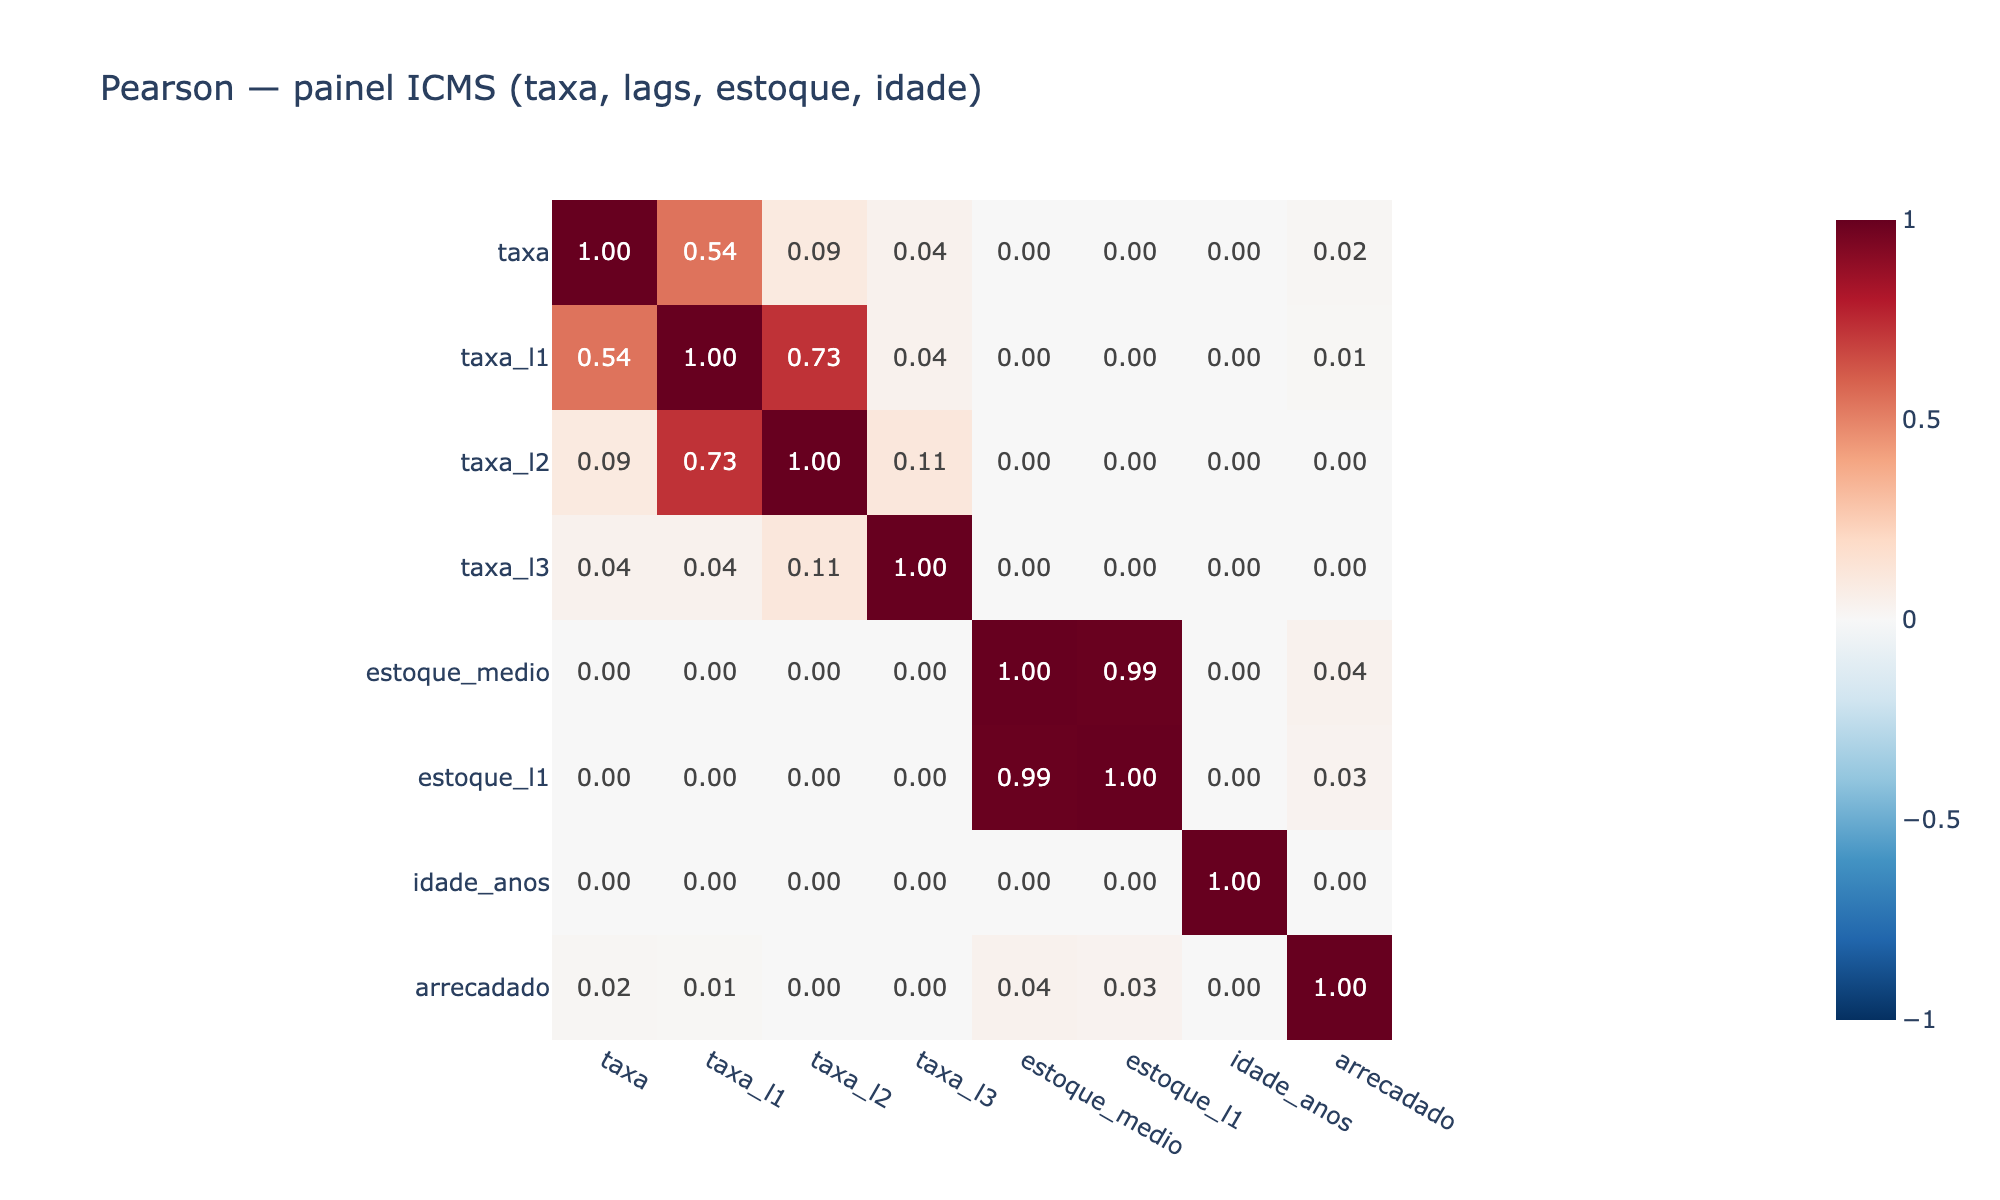

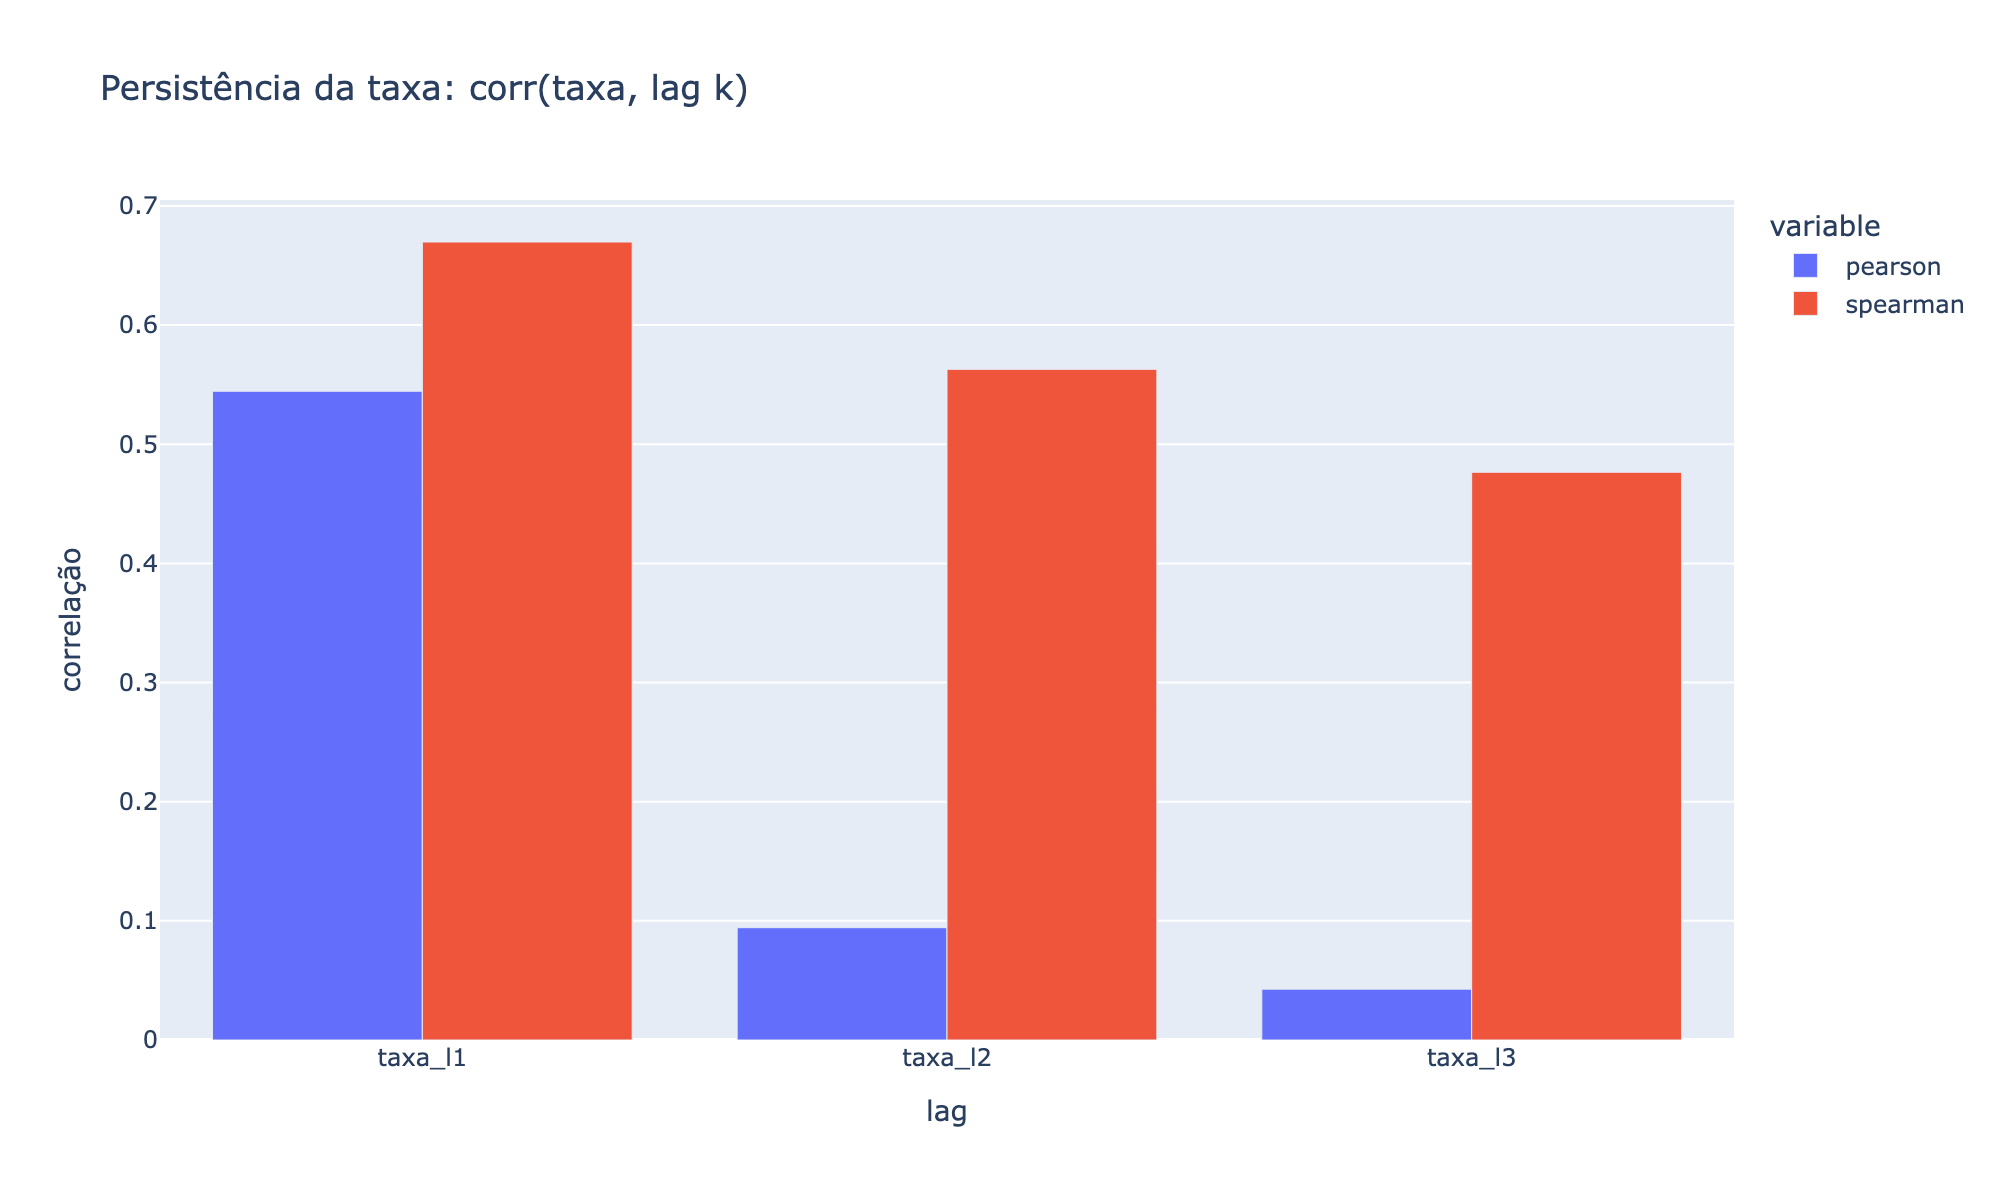

figs salvos


In [17]:
import polars as pl
import plotly.express as px
from pathlib import Path

out = ARTIFACTS if "ARTIFACTS" in globals() else Path.cwd() / "eda_completo_artifacts"
corr_path = out / "corr_lags_icms.csv"
cdf = pl.read_csv(corr_path)
both = pl.concat([
    cdf.select("var_a", "var_b", "pearson"),
    cdf.filter(pl.col("var_a") != pl.col("var_b")).select(
        pl.col("var_b").alias("var_a"), pl.col("var_a").alias("var_b"), "pearson"
    ),
])
vars_order = ["taxa", "taxa_l1", "taxa_l2", "taxa_l3", "estoque_medio", "estoque_l1", "idade_anos", "arrecadado"]
Z = []
for va in vars_order:
    row = []
    for vb in vars_order:
        hit = both.filter((pl.col("var_a") == va) & (pl.col("var_b") == vb))
        row.append(None if hit.height == 0 else hit["pearson"][0])
    Z.append(row)

fig = px.imshow(
    Z, x=vars_order, y=vars_order, color_continuous_scale="RdBu_r", zmin=-1, zmax=1,
    title="Pearson — painel ICMS (taxa, lags, estoque, idade)",
    text_auto=".2f",
)
fig.update_layout(width=720, height=640)
fig.show()
fig.write_html(str(out / "fig_corr_pearson_lags.html"))

auto = cdf.filter(
    (pl.col("var_a") == "taxa") & pl.col("var_b").is_in(["taxa_l1", "taxa_l2", "taxa_l3"])
).select("var_b", "pearson", "spearman")
fig2 = px.bar(
    auto.to_dicts(), x="var_b", y=["pearson", "spearman"], barmode="group",
    title="Persistência da taxa: corr(taxa, lag k)",
    labels={"var_b": "lag", "value": "correlação"},
)
fig2.show()
fig2.write_html(str(out / "fig_autocorr_taxa_lags.html"))
print("figs salvos")



In [18]:
from pathlib import Path
out = ARTIFACTS if "ARTIFACTS" in globals() else Path.cwd() / "eda_completo_artifacts"
lags_path = out / "painel_icms_com_lags.parquet"
corr_path = out / "corr_lags_icms.csv"
ok = lags_path.is_file() and corr_path.is_file() and corr_path.stat().st_size > 0
print("DoD etapa 5:", "PASS" if ok else "FAIL")
print("lags parquet:", lags_path)
print("corr csv:", corr_path)


DoD etapa 5: PASS
lags parquet: /Users/etorebraga/Code/cemepi-ctf-intel-fiscal/projects/macro/notebooks/eda_completo_artifacts/painel_icms_com_lags.parquet
corr csv: /Users/etorebraga/Code/cemepi-ctf-intel-fiscal/projects/macro/notebooks/eda_completo_artifacts/corr_lags_icms.csv


## 6. Três modelos no painel ICMS (grão anual)

Com base na seção 5 (persistência em `taxa_l1`), ajustamos três leituras simples — **ainda descritivas**, não causais — no painel `ID_DEBITO × ano`:

1. **Logit** — probabilidade de arrecadar alguma coisa no ano (`arrecadado > 0`).
2. **Regressão da taxa** — quanto se arrecada relativo ao estoque.
3. **Série agregada** — soma de estoque e arrecadação no ano (visão “caixa” da PGE).

O painel atual é **anual** (não há trimestre na etapa 4). Se a Lívia quiser calendário trimestral, fazemos um recorte depois a partir de `ARRECADACAO` com mês.

Ajuste micro: amostra aleatória de **1 milhão** de linhas com `taxa_l1` preenchido (semente fixa), para caber na RAM do Mac. A série agregada usa **todos** os anos do parquet.


### O que cada modelo estima (definição)

**Logit.** Indicador Y = 1 se o débito arrecadou no ano e 0 caso contrário. O modelo estima a probabilidade de pagamento em função das covariáveis (curva logística).

Covariáveis: lag da taxa (`taxa_l1`), log(1 + estoque), idade da CDA em anos, e dummies de ano.

**Taxa (MQO).** Regressão linear da `taxa` nas mesmas covariáveis (sem a taxa contemporânea no lado direito).

**Agregado.** Em cada ano: soma do estoque, soma da arrecadação e taxa da carteira = arrecadação total / estoque total. Mostra a trajetória da carteira ICMS como um todo.

Interpretação para procuradores: coeficientes dizem **associação** (controle de ano e estoque), não efeito de política.


In [19]:
import duckdb
from pathlib import Path
import numpy as np
import polars as pl
import plotly.express as px
import statsmodels.api as sm
import statsmodels.formula.api as smf

assert fonte_ok
out = ARTIFACTS if "ARTIFACTS" in globals() else Path.cwd() / "eda_completo_artifacts"
lags_path = out / "painel_icms_com_lags.parquet"
assert lags_path.is_file(), "rode a etapa 5 antes (lags)"
tmp = DATA_ROOT / "_duckdb_tmp_eda"
tmp.mkdir(exist_ok=True)
amostra_path = out / "amostra_modelos_1m.parquet"

con = duckdb.connect()
con.execute(f"SET temp_directory='{tmp}'")
con.execute("SET max_temp_directory_size='100GiB'")
con.execute("SET memory_limit='3GB'")
con.execute("SET threads=2")
con.execute("SET preserve_insertion_order=false")

if amostra_path.is_file() and amostra_path.stat().st_size > 0:
    print("SKIP amostra —", amostra_path)
else:
    print("… sorteando 1M linhas com taxa_l1 …")
    con.execute(f"""
    COPY (
      SELECT
        ID_DEBITO, ano, estoque_medio, arrecadado, taxa,
        idade_anos, taxa_l1, estoque_l1,
        (arrecadado > 0)::INTEGER AS y_pago,
        ln(1 + greatest(estoque_medio, 0)) AS log_estoque
      FROM read_parquet('{lags_path}')
      WHERE taxa_l1 IS NOT NULL
        AND estoque_medio IS NOT NULL
        AND idade_anos IS NOT NULL
      USING SAMPLE 1000000
    ) TO '{amostra_path}' (FORMAT PARQUET)
    """)
    print("amostra →", amostra_path)

# agregados anuais na base toda
agg = con.execute(f"""
  SELECT
    ano,
    count(*) AS n,
    sum(estoque_medio) AS estoque_sum,
    sum(arrecadado) AS arrec_sum,
    sum(arrecadado) / nullif(sum(estoque_medio), 0) AS taxa_carteira,
    avg(taxa) AS taxa_media_id,
    avg((arrecadado > 0)::DOUBLE) AS share_pago
  FROM read_parquet('{lags_path}')
  GROUP BY 1
  ORDER BY 1
""").pl()
agg.write_csv(out / "serie_agregada_icms_ano.csv")
print(agg)
con.close()

df = pl.read_parquet(amostra_path).to_pandas()
df["ano"] = df["ano"].astype(int)
print("amostra:", len(df), "anos", df["ano"].min(), "→", df["ano"].max(), "share pago", df["y_pago"].mean().round(3))



… sorteando 1M linhas com taxa_l1 …
amostra → /Users/etorebraga/Code/cemepi-ctf-intel-fiscal/projects/macro/notebooks/eda_completo_artifacts/amostra_modelos_1m.parquet
shape: (11, 7)
┌──────┬─────────┬─────────────┬───────────┬───────────────┬───────────────┬────────────┐
│ ano  ┆ n       ┆ estoque_sum ┆ arrec_sum ┆ taxa_carteira ┆ taxa_media_id ┆ share_pago │
│ ---  ┆ ---     ┆ ---         ┆ ---       ┆ ---           ┆ ---           ┆ ---        │
│ i64  ┆ i64     ┆ f64         ┆ f64       ┆ f64           ┆ f64           ┆ f64        │
╞══════╪═════════╪═════════════╪═══════════╪═══════════════╪═══════════════╪════════════╡
│ 2016 ┆ 1580430 ┆ 3.2070e11   ┆ 8.9458e8  ┆ 0.002789      ┆ 0.196623      ┆ 0.103182   │
│ 2017 ┆ 1722254 ┆ 3.5398e11   ┆ 1.1398e9  ┆ 0.00322       ┆ 0.205164      ┆ 0.109503   │
│ 2018 ┆ 1841277 ┆ 3.8096e11   ┆ 8.9293e8  ┆ 0.002344      ┆ 0.03406       ┆ 0.087316   │
│ 2019 ┆ 2183992 ┆ 4.1062e11   ┆ 1.5230e9  ┆ 0.003709      ┆ 0.106663      ┆ 0.105713   │
│ 2020 

### Como ler os coeficientes (logit e taxa)

No **logit**, um coeficiente positivo em `taxa_l1` significa: débitos que arrecadaram mais no ano anterior têm **maior chance** de arrecadar de novo (tudo o mais constante na amostra). O valor em si não é um “% a mais” direto — olhe também o efeito marginal médio impresso abaixo.

Na **regressão da taxa**, o coeficiente de `taxa_l1` próximo de 0,5 ecoa a correlação da seção 5: cerca de metade da taxa passada “reaparece” na taxa atual, em média linear.

Dummies de `ano` absorvem choques comuns (calendário fiscal, COVID, etc.).


In [20]:
# --- Modelo 1: Logit P(pago) ---
# C × ano como FE via C(ano); amostra 1M
m1 = smf.logit(
    "y_pago ~ taxa_l1 + log_estoque + idade_anos + C(ano)",
    data=df,
).fit(disp=False)
print(m1.summary().tables[1])
# efeito marginal médio de taxa_l1
mfx = m1.get_margeff(at="overall")
print("\nEfeitos marginais médios:")
print(mfx.summary())
# salvar coeficientes
coef1 = (
    pl.DataFrame({
        "param": m1.params.index.astype(str),
        "coef": m1.params.values,
        "pvalue": m1.pvalues.values,
    })
)
coef1.write_csv(out / "modelo1_logit_coefs.csv")
print("Pseudo-R²:", round(m1.prsquared, 4))



                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -0.6879      0.023    -29.600      0.000      -0.733      -0.642
C(ano)[T.2018]    -0.3505      0.020    -17.662      0.000      -0.389      -0.312
C(ano)[T.2019]    -0.3476      0.020    -17.724      0.000      -0.386      -0.309
C(ano)[T.2020]    -0.4910      0.020    -24.990      0.000      -0.530      -0.452
C(ano)[T.2021]    -0.8144      0.021    -38.447      0.000      -0.856      -0.773
C(ano)[T.2022]    -0.9836      0.022    -45.442      0.000      -1.026      -0.941
C(ano)[T.2023]    -1.1537      0.022    -52.655      0.000      -1.197      -1.111
C(ano)[T.2024]    -1.2429      0.022    -55.882      0.000      -1.286      -1.199
C(ano)[T.2025]    -1.4889      0.023    -63.572      0.000      -1.535      -1.443
C(ano)[T.2026]    -2.1009      0.028    -75.397      0.000      -2.156      -2.046
taxa

In [21]:
# --- Modelo 2: MQO da taxa ---
m2 = smf.ols(
    "taxa ~ taxa_l1 + log_estoque + idade_anos + C(ano)",
    data=df,
).fit()
print(m2.summary().tables[1])
coef2 = pl.DataFrame({
    "param": m2.params.index.astype(str),
    "coef": m2.params.values,
    "pvalue": m2.pvalues.values,
})
coef2.write_csv(out / "modelo2_taxa_ols_coefs.csv")
print("R²:", round(m2.rsquared, 4), "  N:", int(m2.nobs))



                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          1.4522      0.145     10.040      0.000       1.169       1.736
C(ano)[T.2018]    -0.1788      0.131     -1.369      0.171      -0.435       0.077
C(ano)[T.2019]    -0.1437      0.129     -1.115      0.265      -0.396       0.109
C(ano)[T.2020]    -0.1947      0.133     -1.467      0.142      -0.455       0.065
C(ano)[T.2021]    -0.1717      0.132     -1.298      0.194      -0.431       0.088
C(ano)[T.2022]    -0.0904      0.130     -0.697      0.486      -0.344       0.164
C(ano)[T.2023]    -0.1744      0.127     -1.371      0.170      -0.424       0.075
C(ano)[T.2024]     0.2088      0.126      1.660      0.097      -0.038       0.455
C(ano)[T.2025]    -0.0968      0.124     -0.781      0.435      -0.340       0.146
C(ano)[T.2026]    -0.2612      0.122     -2.137      0.033      -0.501      -0.022
taxa

### Como ler a série agregada

`estoque_sum` é o estoque ICMS somado no painel naquele ano; `arrec_sum` é o que entrou em GARE; `taxa_carteira = arrec/estoque` da carteira inteira; `share_pago` é a fração de débitos com alguma arrecadação.

Se a taxa da carteira cai enquanto o estoque sobe, a dívida “engorda” mais rápido do que a cobrança — leitura de gestão, ainda sem causalidade.


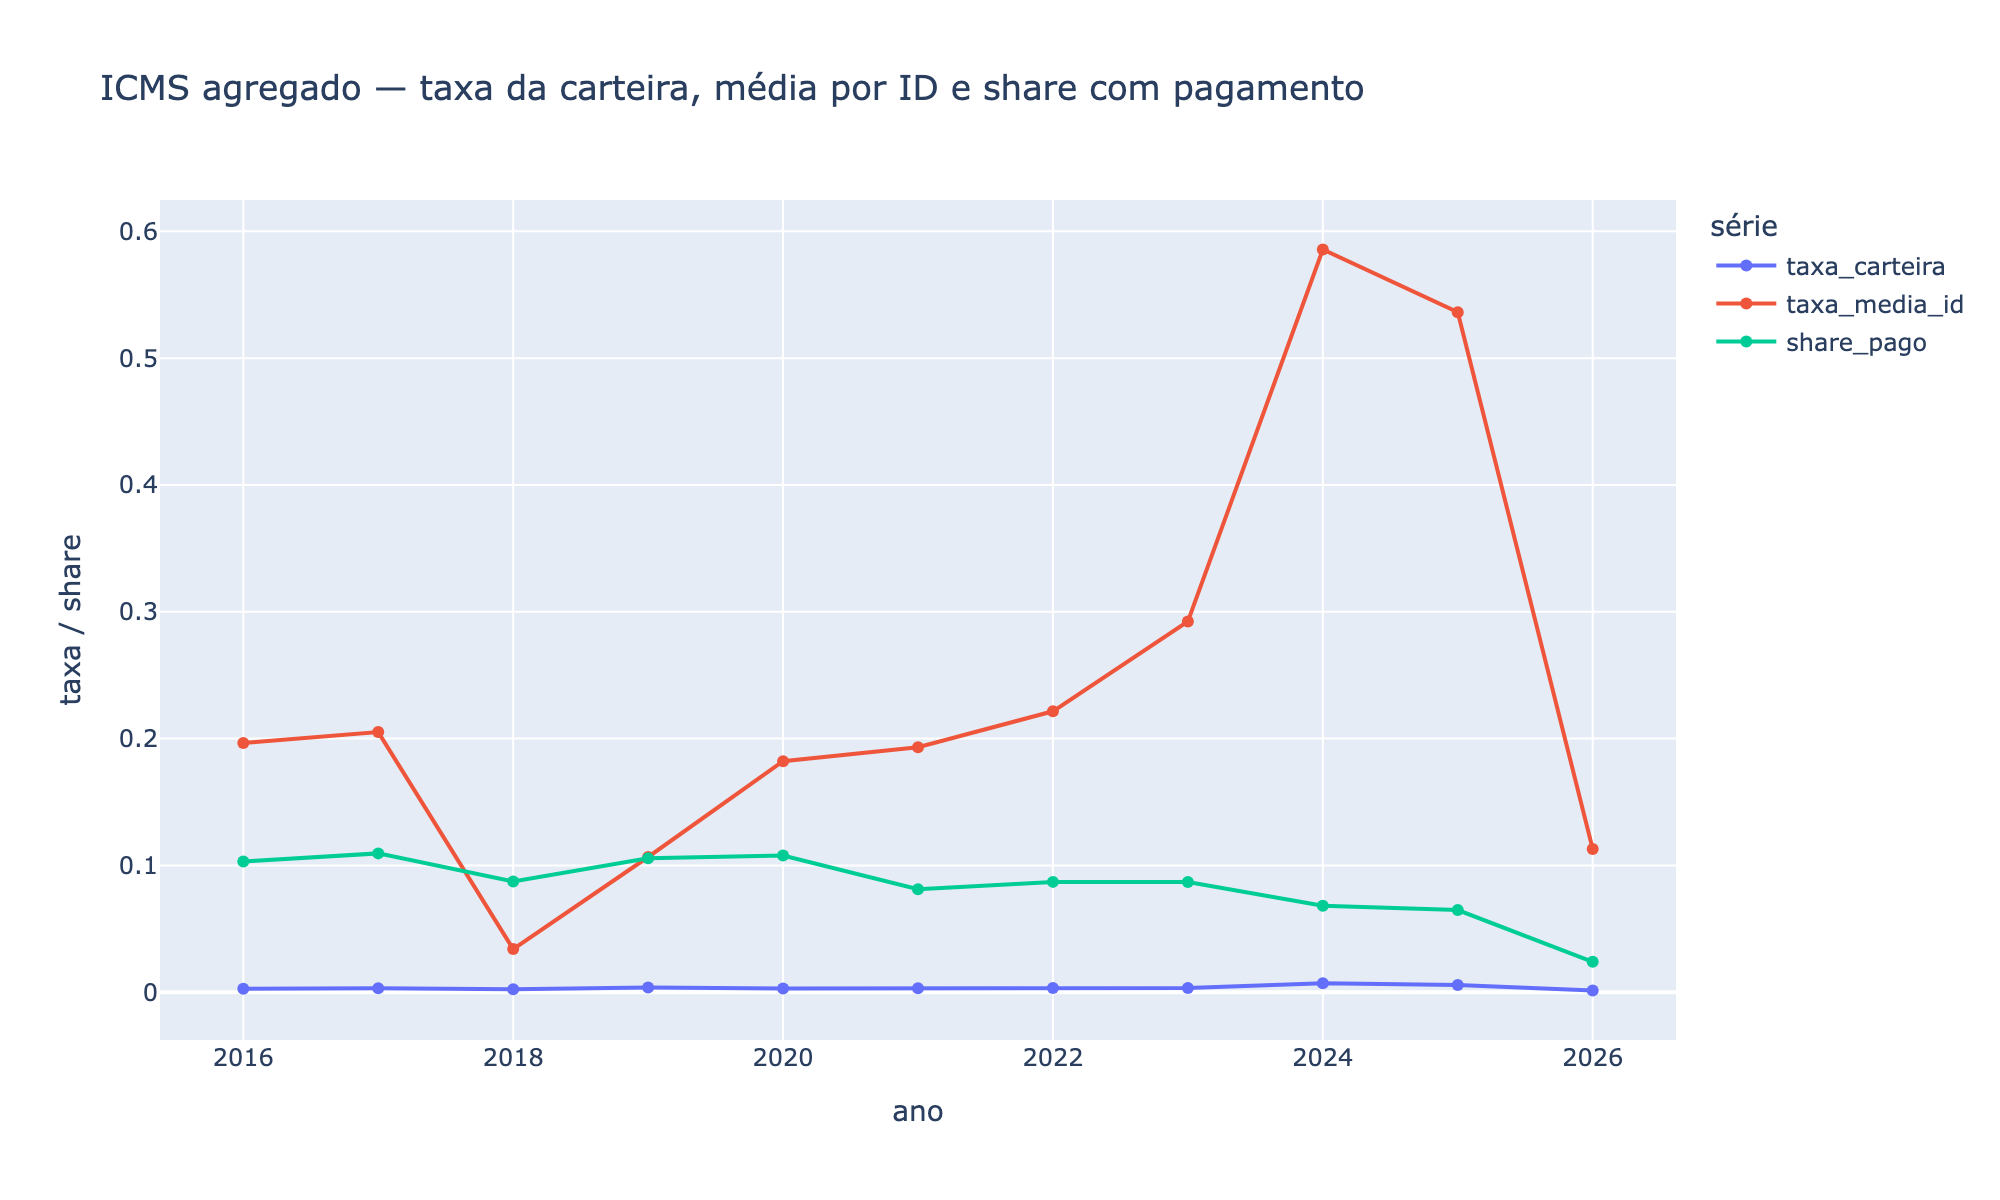

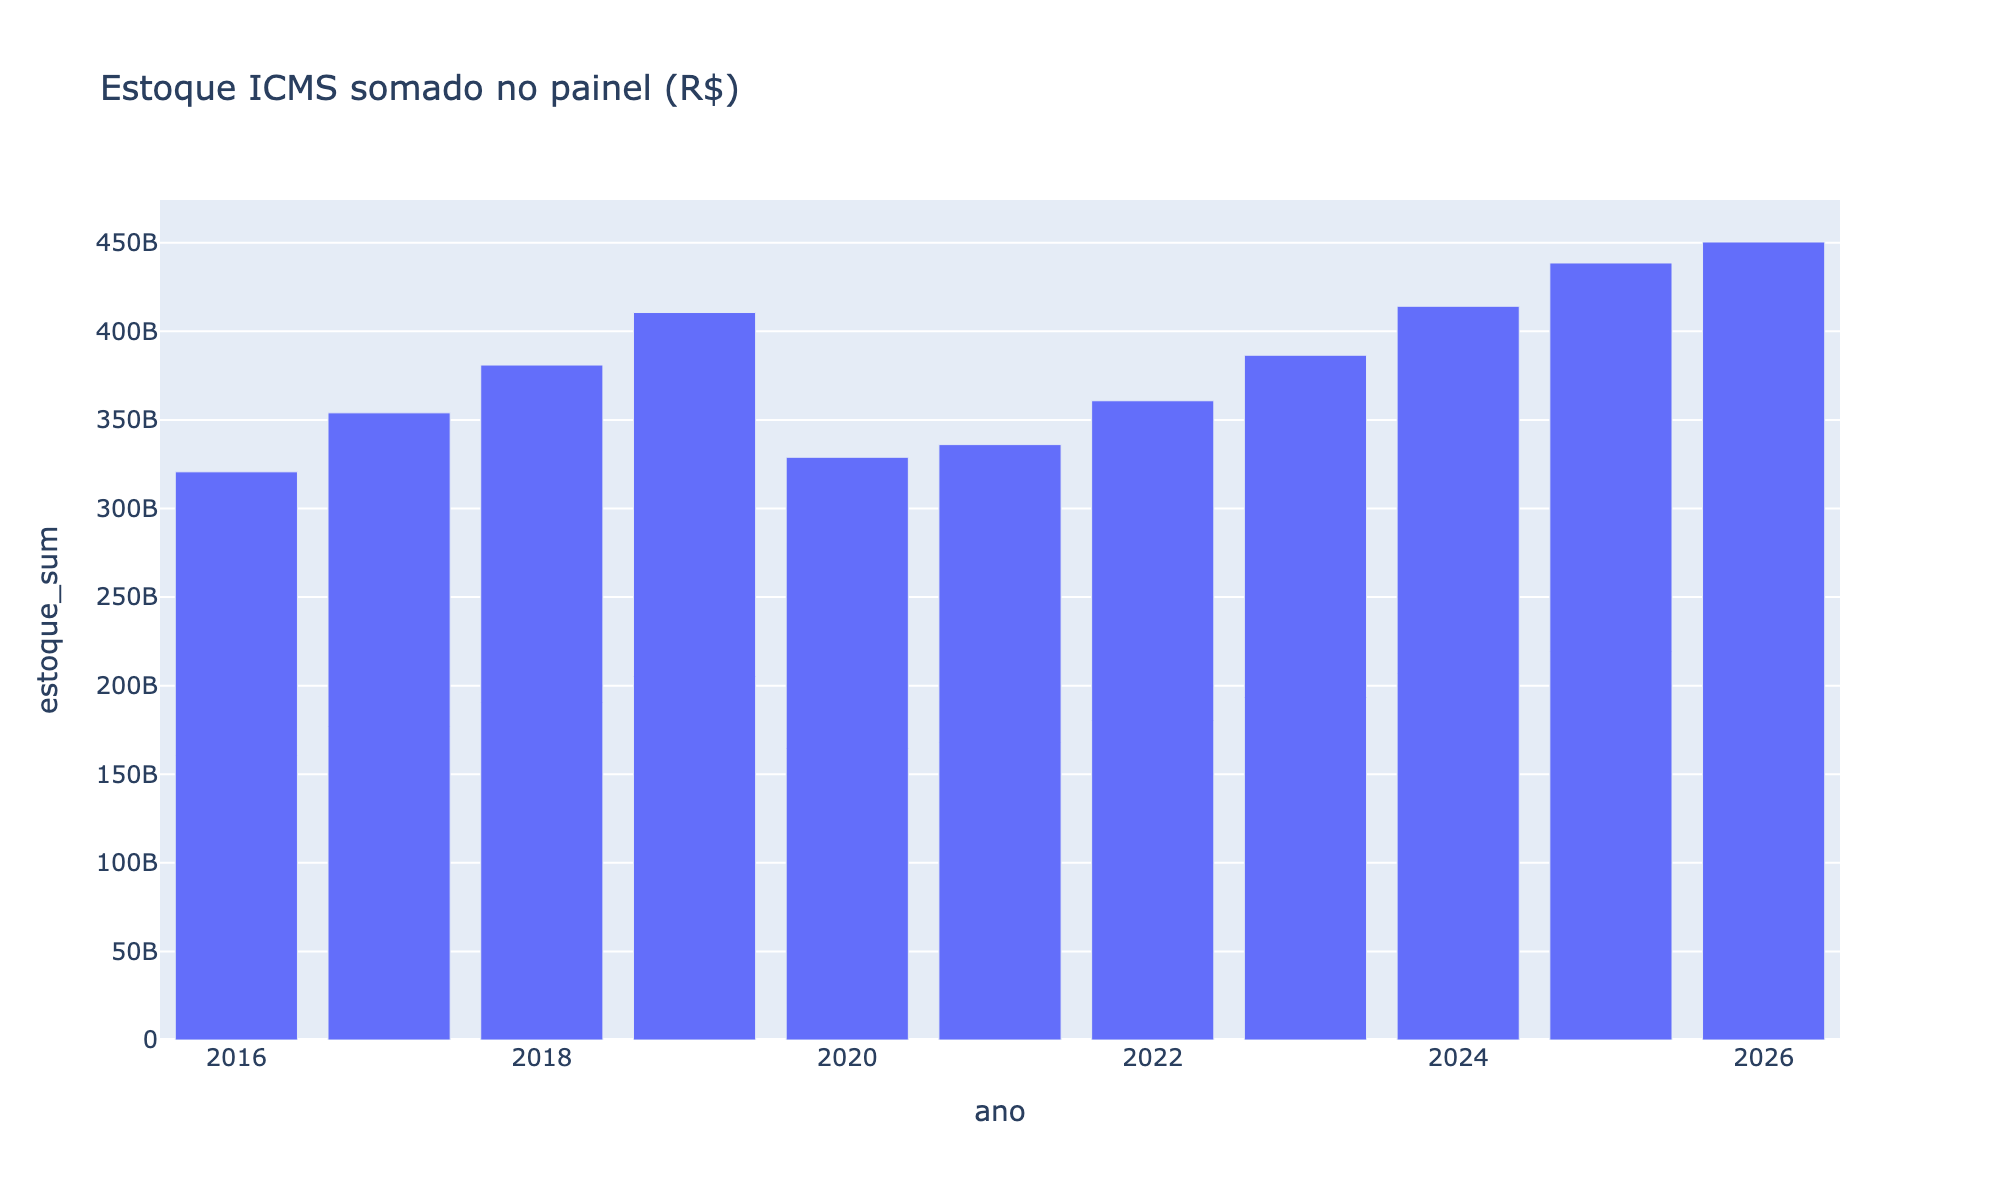

                            OLS Regression Results                            
Dep. Variable:          taxa_carteira   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                 -0.109
Method:                 Least Squares   F-statistic:                    0.1191
Date:                Fri, 02 Oct 2026   Prob (F-statistic):              0.739
Time:                        21:36:15   Log-Likelihood:                 50.633
No. Observations:                  10   AIC:                            -97.27
Df Residuals:                       8   BIC:                            -96.66
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0031      0.002      1.991      0.0

In [22]:
# --- Modelo 3: trajetória agregada + AR(1) na taxa da carteira ---
agg_pd = agg.to_pandas().sort_values("ano")
fig = px.line(
    agg_pd, x="ano", y=["taxa_carteira", "taxa_media_id", "share_pago"],
    markers=True,
    title="ICMS agregado — taxa da carteira, média por ID e share com pagamento",
    labels={"value": "taxa / share", "variable": "série"},
)
fig.show()
fig.write_html(str(out / "fig_serie_agregada_icms.html"))

fig_e = px.bar(
    agg_pd, x="ano", y="estoque_sum",
    title="Estoque ICMS somado no painel (R$)",
)
fig_e.show()
fig_e.write_html(str(out / "fig_estoque_agregado_ano.html"))

# AR(1) simples na taxa da carteira (poucos anos — só descritivo)
agg_pd = agg_pd.copy()
agg_pd["taxa_l1"] = agg_pd["taxa_carteira"].shift(1)
m3 = smf.ols("taxa_carteira ~ taxa_l1", data=agg_pd.dropna()).fit()
print(m3.summary())
pl.DataFrame({
    "param": m3.params.index.astype(str),
    "coef": m3.params.values,
    "pvalue": m3.pvalues.values,
}).write_csv(out / "modelo3_ar1_taxa_carteira.csv")
print("DoD parcial modelo 3: anos=", len(agg_pd))



In [23]:
from pathlib import Path
out = ARTIFACTS if "ARTIFACTS" in globals() else Path.cwd() / "eda_completo_artifacts"
need = [
    "amostra_modelos_1m.parquet",
    "serie_agregada_icms_ano.csv",
    "modelo1_logit_coefs.csv",
    "modelo2_taxa_ols_coefs.csv",
    "modelo3_ar1_taxa_carteira.csv",
    "fig_serie_agregada_icms.html",
]
ok = all((out / f).is_file() for f in need)
print("DoD etapa 6:", "PASS" if ok else "FAIL")
for f in need:
    print(" ", "OK" if (out / f).is_file() else "MISS", f)


DoD etapa 6: PASS
  OK amostra_modelos_1m.parquet
  OK serie_agregada_icms_ano.csv
  OK modelo1_logit_coefs.csv
  OK modelo2_taxa_ols_coefs.csv
  OK modelo3_ar1_taxa_carteira.csv
  OK fig_serie_agregada_icms.html
